<a href="https://colab.research.google.com/github/thomaslu678/Praxis-Lab-25-26/blob/main/clean/16_VIT_No_Test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
from datetime import timedelta
import scipy.stats as stats
import rasterio
from rasterio.transform import from_origin
from rasterio.features import rasterize
import geopandas as gpd
from shapely.geometry import Point
import requests
import random
import os
import math
import copy
import sys
import gc
from io import StringIO

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from numpy.lib.stride_tricks import sliding_window_view

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import shap

import seaborn as sns

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Populate data_dict

In [4]:
path_to_data = "/content/drive/MyDrive/Year 2/Fall 2025/HONOR 3700/Data/Github/"
num_cases = 23

In [5]:
data_dict = {}

In [6]:
# Populate the dfs
for i in range(num_cases):
    case_dict = {}
    case_dict["data_df"] = pd.read_csv(path_to_data + str(i) + "_data.csv")
    case_dict["metadata_df"] = pd.read_csv(path_to_data + str(i) + "_metadata.csv")

    data_dict[i] = case_dict

In [7]:
# Populate lookups
for i in range(num_cases):
    case_dict = data_dict[i]
    unique_points_df = case_dict['data_df'].drop_duplicates(subset=['fid'], keep='first')[["fid", "row_index", "col_index"]]
    case_dict["unique_points"] = unique_points_df
    case_dict["lookup"] = {(r,c):pid for r,c,pid in zip(unique_points_df.row_index, unique_points_df.col_index, unique_points_df.fid)}


In [8]:
# Expect size to be an odd integer
def get_patches(df, size, lookup):

    patches = []

    for r,c in zip(df.row_index, df.col_index):

        valid = True
        patch = []

        for dr in range(-(size // 2) , (size // 2)+1):
            row_vals = []
            for dc in range(-(size // 2) , (size // 2)+1):

                key = (r+dr, c+dc)

                if key not in lookup:
                    valid = False
                    break

                row_vals.append(lookup[key])

            if not valid:
                break

            patch.append(row_vals)

        if valid:
            patches.append(patch)

    patches = np.array(patches)

    return patches

In [9]:
PATCH_SIZE = 5

In [10]:
# Populate patches
for i in range(num_cases):
    case_dict = data_dict[i]
    index_patches = get_patches(case_dict["unique_points"], PATCH_SIZE, case_dict["lookup"])
    case_dict["index_patches"] = index_patches

In [11]:
for i in range(num_cases):
    if (len(data_dict[i]['index_patches']) == 0):
        print(i)

0
2
9
16


In [12]:
# Convert time in metadata to datetime, sort
for i in range(num_cases):
    case_dict = data_dict[i]
    case_dict['metadata_df']['time'] = pd.to_datetime(case_dict['metadata_df']['time'])
    case_dict['metadata_df'] = case_dict['metadata_df'].sort_values(by='time', ascending=True)

In [13]:
def add_time_features(df):
    if df.empty:
        return
    df = df.copy()

    # Convert time strings to datetime
    t = pd.to_datetime(df["time"])

    # Basic date features
    df["year"] = t.dt.year
    df["month"] = t.dt.month
    df["day_of_year"] = t.dt.dayofyear

    # Seasonality
    df["seasonality"] = np.sin(
        2 * np.pi * df["day_of_year"] / 365
    )

    # Difference from previous observation, in days
    df["diff_prev"] = (
        t.diff()
        .dt.total_seconds()
        .div(86400)
        .fillna(0)
    )

    # Difference from first observation, in days
    df["diff_first"] = (
        t - t.iloc[0]
    ).dt.total_seconds().div(86400)

    return df

In [14]:
# Convert time in metadata to datetime, sort
for i in range(num_cases):
    case_dict = data_dict[i]
    case_dict['metadata_df'] = add_time_features(case_dict['metadata_df'])

In [15]:
# Temp populate similiarity scores
for i in range(num_cases):
    case_dict = data_dict[i]
    case_dict['similarity_score'] = 1

In [16]:
# Copy data dict that has non-zero rows for data and index_patches
data_dict_filtered = {
    i: case_dict
    for i, case_dict in data_dict.items()
    if (len(case_dict.get('unique_points', [])) > 0 and len(case_dict['index_patches'] > 0))
}

In [17]:
# Remove empty cases
list_of_empty_patches = [0, 2, 9, 16]
for case_id in list_of_empty_patches:
    _ = data_dict.pop(case_id)

In [18]:
data_dict.keys()

dict_keys([1, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15, 17, 18, 19, 20, 21, 22])

In [19]:
for i in data_dict.keys():
    data_dict[i]['metadata_df'] = data_dict[i]['metadata_df'].reset_index(drop=True)

In [20]:
bad_data_url = "https://raw.githubusercontent.com/thomaslu678/Praxis-Lab-25-26/refs/heads/main/assets/points/bad_data.csv"
bad_data_df = pd.read_csv(bad_data_url)

In [21]:
def remove_bad_data(data_dict, bad_data_df):
    report = []

    for case_id, bad_case_df in bad_data_df.groupby("case_id"):
        case_key = int(case_id)

        if case_key not in data_dict:
            report.append({
                "case_id": case_key,
                "bad_rows": len(bad_case_df),
                "matched": 0,
                "removed": 0,
                "unmatched": len(bad_case_df),
            })
            continue

        case_dict = data_dict[case_key]
        data_df = case_dict["data_df"]

        # Primary keys to remove
        bad_keys = set(
            zip(bad_case_df["fid"], bad_case_df["mission_id"])
        )

        # Identify rows matching those keys
        row_keys = list(zip(data_df["fid"], data_df["mission_id"]))
        mask = pd.Series(row_keys, index=data_df.index).isin(bad_keys)

        removed = int(mask.sum())

        # Update the dataframe in-place within the nested dict
        case_dict["data_df"] = data_df.loc[~mask].copy()

        report.append({
            "case_id": case_key,
            "bad_rows": len(bad_case_df),
            "matched": removed,
            "removed": removed,
            "unmatched": len(bad_case_df) - removed,
        })

    report_df = pd.DataFrame(report)

    return data_dict, report_df

In [22]:
data_dict, report_df = remove_bad_data(data_dict, bad_data_df)

In [23]:
report_df

,case_id,bad_rows,matched,removed,unmatched
0,1,3092,1537,1537,1555
1,3,7226,7226,7226,0
2,4,2016,2016,2016,0
3,5,4886,4886,4886,0
4,6,2994,2994,2994,0
5,7,4443,4443,4443,0
6,8,833,833,833,0
7,9,23,0,0,23
8,10,1872,1872,1872,0
9,11,1996,1996,1996,0


In [24]:
def populate_index_patch_metadata(data_dict):
    for case_id in data_dict.keys():
        case_data = data_dict[case_id]

        data_df = case_data["data_df"]
        metadata_df = case_data["metadata_df"].reset_index(drop=True)

        # Normalize FIDs once
        data_fids = data_df["fid"].astype(str)
        data_missions = data_df["mission_id"]

        # Build:
        #   mission_id -> set of FIDs available for that mission
        mission_to_fids = (
            data_df.assign(fid=data_fids)
            .groupby("mission_id")["fid"]
            .agg(set)
            .to_dict()
        )

        # Get the original patches
        index_patches = case_data["index_patches"]

        new_index_patches = []

        for index_patch in index_patches:
            # Flatten 2D patch and normalize FIDs
            patch_fids = set(str(fid) for fid in index_patch.flatten())

            # Find missions that contain every FID in the patch
            valid_mission_ids = [
                mission_id
                for mission_id, mission_fids in mission_to_fids.items()
                if patch_fids.issubset(mission_fids)
            ]

            # Convert mission IDs to metadata_df indices
            metadata_indices = metadata_df.index[
                metadata_df["mission_id"].isin(valid_mission_ids)
            ].tolist()

            new_index_patches.append({
                "data_indices": index_patch,
                "metadata_indices": metadata_indices,
            })

        # Replace original patches in place
        case_data["index_patches"] = new_index_patches

In [25]:
populate_index_patch_metadata(data_dict)

In [26]:
data_dict[1]['index_patches'][0].keys()

dict_keys(['data_indices', 'metadata_indices'])

# Run new workflow

In [92]:
"""End-to-end Landsat patch time-series training workflow (patch-specific missions).

Expected input
--------------
data_dict[case_id] is a mapping containing:
  data_df, metadata_df, index_patches, similarity_score

Each index_patches item is a mapping containing a 2-D ``data_indices`` patch
and a 1-D, temporally ordered ``metadata_indices`` sequence.

The dataset builds a compact index of (case, patch, window start) records and
materializes each [T,C,H,W] example only when DataLoader requests it.
"""

from __future__ import annotations

import copy
import random
from dataclasses import dataclass
from typing import Any, Hashable, Mapping, Optional, Sequence

import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset


BAND_COLUMNS = ("Blue", "Green", "Red", "NIR")
METADATA_COLUMNS = (
    "cloud_cover", "sun_azimuth", "sun_elevation", "year", "month",
    "day_of_year", "seasonality",
)


@dataclass(frozen=True)
class WorkflowConfig:
    window: int = 50
    samples_per_patch: int = 10

    use_data_subset: bool = False
    data_subset_fraction: float = 1.0

    # Required. This case is untouched until the best validation model is chosen.
    test_case_id: Optional[Hashable] = None
    # Fraction of the remaining case IDs assigned to validation.
    validation_fraction: float = 0.2
    batch_size: int = 8
    num_epochs: int = 20
    learning_rate: float = 1e-3
    weight_decay: float = 0.0
    num_workers: int = 4
    seed: int = 1024
    accum_steps: int = 1
    use_amp: bool = False
    max_grad_norm: Optional[float] = None
    pin_memory: bool = True
    persistent_workers: bool = True
    # True implements "if any pixel is missing, discard the patch" over all 10
    # selected windows. False discards only the incomplete sample window.
    discard_entire_patch_if_incomplete: bool = True


@dataclass
class PreparedCase:
    case_id: Hashable
    missions: np.ndarray                 # [M]
    bands: np.ndarray                    # [M, P, C]
    lst: np.ndarray                      # [M, P]
    metadata: np.ndarray                 # [M, E]
    fid_to_pos: dict[Any, int]
    patches: np.ndarray                  # [N, H, W], integer positions into P
    patch_metadata_indices: tuple[np.ndarray, ...]  # per-patch metadata iloc values
    similarity_score: float


@dataclass(frozen=True)
class SampleRef:
    case_id: Hashable
    patch_idx: int
    start: int


@dataclass(frozen=True)
class NormalizationStats:
    cube_mean: np.ndarray
    cube_std: np.ndarray
    emb_mean: np.ndarray
    emb_std: np.ndarray
    y_mean: float
    y_std: float


def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def evenly_spaced_starts(num_times: int, window: int, count: int) -> np.ndarray:
    """Return `count` starts spanning [0, num_times-window].

    If fewer than `count` distinct windows exist, all distinct starts are used;
    duplicate samples are deliberately not created.
    """
    max_start = num_times - window
    if max_start < 0:
        return np.empty(0, dtype=np.int64)
    n = min(count, max_start + 1)
    return np.unique(np.rint(np.linspace(0, max_start, n)).astype(np.int64))


def _require_columns(df: pd.DataFrame, columns: Sequence[str], label: str) -> None:
    missing = sorted(set(columns) - set(df.columns))
    if missing:
        raise ValueError(f"{label} is missing columns: {missing}")


def prepare_case(
    case_id: Hashable,
    case: Mapping[str, Any],
    band_columns: Sequence[str] = BAND_COLUMNS,
    metadata_columns: Sequence[str] = METADATA_COLUMNS,
) -> PreparedCase:
    """Validate one case and convert DataFrames to dense read-only arrays."""
    for key in ("data_df", "metadata_df", "index_patches", "similarity_score"):
        if key not in case:
            raise ValueError(f"Case {case_id!r} is missing key {key!r}")

    data = case["data_df"]
    meta = case["metadata_df"].copy()
    _require_columns(data, ("fid", "mission_id", "LST_K", *band_columns), "data_df")
    _require_columns(meta, ("mission_id", "time", *metadata_columns), "metadata_df")
    if data.duplicated(["fid", "mission_id"]).any():
        raise ValueError(f"Case {case_id!r}: (fid, mission_id) must be unique")
    if meta["mission_id"].duplicated().any():
        raise ValueError(f"Case {case_id!r}: metadata mission_id must be unique")

    meta["time"] = pd.to_datetime(meta["time"], errors="raise")
    # metadata_indices are positional indices into the caller's metadata_df.
    # Sorting here would silently change their meaning, so require ordered input.
    if not meta["time"].is_monotonic_increasing:
        raise ValueError(
            f"Case {case_id!r}: metadata_df must already be sorted by time because "
            "patch metadata_indices are positional row indices"
        )
    meta = meta.reset_index(drop=True)
    meta_values = meta.loc[:, list(metadata_columns)].apply(pd.to_numeric, errors="raise")
    metadata = meta_values.to_numpy(dtype=np.float32, copy=True)
    missions = meta["mission_id"].to_numpy(copy=True)

    # Preserve fid identity; sorting is unnecessary because patches map by value.
    fids = pd.unique(data["fid"])
    fid_to_pos = {fid: i for i, fid in enumerate(fids)}
    mission_to_pos = {mid: i for i, mid in enumerate(missions)}
    bands = np.full((len(missions), len(fids), len(band_columns)), np.nan, np.float32)
    lst = np.full((len(missions), len(fids)), np.nan, np.float32)

    row_m = data["mission_id"].map(mission_to_pos)
    unknown = row_m.isna()
    if unknown.any():
        values = data.loc[unknown, "mission_id"].drop_duplicates().tolist()[:5]
        raise ValueError(f"Case {case_id!r}: data_df missions absent from metadata_df: {values}")
    row_p = data["fid"].map(fid_to_pos).to_numpy(dtype=np.int64)
    row_m = row_m.to_numpy(dtype=np.int64)
    bands[row_m, row_p] = data.loc[:, list(band_columns)].to_numpy(dtype=np.float32)
    lst[row_m, row_p] = pd.to_numeric(data["LST_K"], errors="raise").to_numpy(np.float32)

    raw_patches = case["index_patches"]
    if not isinstance(raw_patches, (list, tuple, np.ndarray)) or len(raw_patches) == 0:
        raise ValueError(f"Case {case_id!r}: index_patches must be a nonempty sequence of dictionaries")
    patch_positions_list = []
    patch_metadata_indices = []
    expected_shape = None
    for patch_idx, patch in enumerate(raw_patches):
        if not isinstance(patch, Mapping) or not {"data_indices", "metadata_indices"} <= set(patch):
            raise ValueError(
                f"Case {case_id!r}, patch {patch_idx}: expected keys "
                "'data_indices' and 'metadata_indices'"
            )
        data_indices = np.asarray(patch["data_indices"])
        if data_indices.ndim != 2:
            raise ValueError(f"Case {case_id!r}, patch {patch_idx}: data_indices must be 2-D")
        if expected_shape is None:
            expected_shape = data_indices.shape
        elif data_indices.shape != expected_shape:
            raise ValueError(
                f"Case {case_id!r}, patch {patch_idx}: patch shape {data_indices.shape} "
                f"does not match {expected_shape}"
            )
        try:
            pos = np.fromiter(
                (fid_to_pos[fid] for fid in data_indices.reshape(-1)),
                dtype=np.int64,
                count=data_indices.size,
            ).reshape(data_indices.shape)
        except KeyError as exc:
            raise ValueError(
                f"Case {case_id!r}, patch {patch_idx}: unknown fid {exc.args[0]!r}"
            ) from exc

        meta_idx = np.asarray(patch["metadata_indices"])
        if meta_idx.ndim != 1:
            raise ValueError(f"Case {case_id!r}, patch {patch_idx}: metadata_indices must be 1-D")
        if not np.issubdtype(meta_idx.dtype, np.integer):
            if not np.equal(meta_idx, np.floor(meta_idx)).all():
                raise ValueError(f"Case {case_id!r}, patch {patch_idx}: metadata_indices must be integers")
        meta_idx = meta_idx.astype(np.int64, copy=True)
        if ((meta_idx < 0) | (meta_idx >= len(meta))).any():
            raise ValueError(
                f"Case {case_id!r}, patch {patch_idx}: metadata index outside [0, {len(meta)-1}]"
            )
        if len(meta_idx) > 1 and not np.all(np.diff(meta_idx) > 0):
            raise ValueError(
                f"Case {case_id!r}, patch {patch_idx}: metadata_indices must be unique "
                "and strictly increasing in temporal order"
            )
        patch_positions_list.append(pos)
        patch_metadata_indices.append(meta_idx)
    patch_positions = np.stack(patch_positions_list)

    score = float(case["similarity_score"])
    if not np.isfinite(score) or score <= 0:
        raise ValueError(f"Case {case_id!r}: similarity_score must be finite and > 0")
    return PreparedCase(case_id, missions, bands, lst, metadata, fid_to_pos,
                        patch_positions, tuple(patch_metadata_indices), score)


def prepare_all_cases(data_dict: Mapping[Hashable, Mapping[str, Any]]) -> dict[Hashable, PreparedCase]:
    if not data_dict:
        raise ValueError("data_dict is empty")
    return {case_id: prepare_case(case_id, case) for case_id, case in data_dict.items()}


def build_sample_index(
    cases: Mapping[Hashable, PreparedCase],
    case_ids: Sequence[Hashable],
    window: int,
    samples_per_patch: int,
    discard_entire_patch_if_incomplete: bool = True,
) -> tuple[list[SampleRef], dict[Hashable, dict[str, Any]]]:
    """Create valid sample references and explain every rejected window.

    For each patch, window starts refer to positions in that patch's own
    ``metadata_indices`` sequence—not consecutive rows of the full metadata
    table. A window is valid only when all four conditions hold:
      1. it contains exactly ``window`` available missions;
      2. every band is finite for every pixel at every timestamp;
      3. every requested metadata feature is finite at every timestamp; and
      4. the center pixel has a finite LST_K at the final timestamp.

    Missing ``(mission_id, fid)`` rows were represented as NaN by
    :func:`prepare_case`, so condition 2 detects both absent rows and explicit
    NaN/inf band values.
    """
    refs: list[SampleRef] = []
    report: dict[Hashable, dict[str, Any]] = {}
    for case_id in case_ids:
        print("Build sample index on " + str(case_id))
        c = cases[case_id]
        refs_before = len(refs)
        kept_patches = rejected_patches = rejected_windows = 0
        cube_failed_windows = metadata_failed_windows = target_failed_windows = 0
        patches_too_short = candidate_windows = 0
        available_counts = []
        for patch_idx, positions_2d in enumerate(c.patches):
            available = c.patch_metadata_indices[patch_idx]
            available_counts.append(len(available))
            starts = evenly_spaced_starts(len(available), window, samples_per_patch)
            if len(starts) == 0:
                patches_too_short += 1
                continue
            candidate_windows += len(starts)
            positions = positions_2d.reshape(-1)
            center_pos = positions_2d[positions_2d.shape[0] // 2, positions_2d.shape[1] // 2]
            valid_starts = []
            for start in starts:
                stop = int(start) + window
                time_idx = available[int(start):stop]
                cube_ok = np.isfinite(c.bands[time_idx][:, positions, :]).all()
                meta_ok = np.isfinite(c.metadata[time_idx]).all()
                target_ok = np.isfinite(c.lst[time_idx[-1], center_pos])
                cube_failed_windows += int(not cube_ok)
                metadata_failed_windows += int(not meta_ok)
                target_failed_windows += int(not target_ok)
                if cube_ok and meta_ok and target_ok:
                    valid_starts.append(int(start))
                else:
                    rejected_windows += 1
            if discard_entire_patch_if_incomplete and len(valid_starts) != len(starts):
                rejected_patches += 1
                continue
            if valid_starts:
                kept_patches += 1
                refs.extend(SampleRef(case_id, patch_idx, s) for s in valid_starts)
        report[case_id] = {
            "candidate_patches": len(c.patches), "kept_patches": kept_patches,
            "rejected_patches": rejected_patches, "kept_samples": len(refs) - refs_before,
            "candidate_windows": candidate_windows,
            "rejected_windows": rejected_windows,
            "patches_too_short": patches_too_short,
            "min_available_missions": int(np.min(available_counts)),
            "median_available_missions": float(np.median(available_counts)),
            "max_available_missions": int(np.max(available_counts)),
            # Failure counts overlap: one window can fail multiple conditions.
            "cube_failed_windows": cube_failed_windows,
            "metadata_failed_windows": metadata_failed_windows,
            "target_failed_windows": target_failed_windows,
            "finite_band_fraction": float(np.isfinite(c.bands).mean()),
            "complete_mission_pixel_fraction": float(np.isfinite(c.bands).all(axis=2).mean()),
            "finite_metadata_fraction": float(np.isfinite(c.metadata).mean()),
            "invalid_metadata_rows": int((~np.isfinite(c.metadata).all(axis=1)).sum()),
            "invalid_metadata_columns": [
                METADATA_COLUMNS[i]
                for i in np.flatnonzero(~np.isfinite(c.metadata).all(axis=0))
            ],
            "finite_lst_fraction": float(np.isfinite(c.lst).mean()),
            "discard_entire_patch_if_incomplete": discard_entire_patch_if_incomplete,
        }
    return refs, report


def _safe_mean_std(x: np.ndarray, axes) -> tuple[np.ndarray, np.ndarray]:
    mean = np.nanmean(x, axis=axes, dtype=np.float64)
    std = np.nanstd(x, axis=axes, dtype=np.float64)
    std = np.where(std < 1e-8, 1.0, std)
    return np.asarray(mean, np.float32), np.asarray(std, np.float32)


def compute_train_stats_for_window(cases, train_case_ids, train_refs, window: int) -> NormalizationStats:
    band_rows = np.concatenate([cases[k].bands.reshape(-1, cases[k].bands.shape[-1]) for k in train_case_ids])
    emb_rows = np.concatenate([cases[k].metadata for k in train_case_ids])
    cube_mean, cube_std = _safe_mean_std(band_rows, axes=0)
    emb_mean, emb_std = _safe_mean_std(emb_rows, axes=0)
    ys = []
    for r in train_refs:
        c = cases[r.case_id]
        p = c.patches[r.patch_idx]
        center = p[p.shape[0] // 2, p.shape[1] // 2]
        time_idx = c.patch_metadata_indices[r.patch_idx][r.start:r.start + window]
        ys.append(c.lst[time_idx[-1], center])
    if not ys:
        raise ValueError("No valid training samples were generated")
    y_mean = float(np.mean(ys, dtype=np.float64))
    y_std = float(np.std(ys, dtype=np.float64))
    if y_std < 1e-8:
        y_std = 1.0
    return NormalizationStats(cube_mean, cube_std, emb_mean, emb_std, y_mean, y_std)


class LandsatSequenceDataset(Dataset):
    def __init__(self, cases, refs, window: int, stats: NormalizationStats):
        self.cases, self.refs, self.window, self.stats = cases, list(refs), window, stats

    def __len__(self):
        return len(self.refs)

    def __getitem__(self, idx):
        r = self.refs[idx]
        c = self.cases[r.case_id]
        pos2d = c.patches[r.patch_idx]
        stop = r.start + self.window
        time_idx = c.patch_metadata_indices[r.patch_idx][r.start:stop]
        # Advanced indexing gives [T,H,W,C], then transpose to [T,C,H,W].
        cube = c.bands[time_idx][:, pos2d, :].transpose(0, 3, 1, 2).copy()
        emb = c.metadata[time_idx].copy()
        center = pos2d[pos2d.shape[0] // 2, pos2d.shape[1] // 2]
        y = float(c.lst[time_idx[-1], center])
        cube = (cube - self.stats.cube_mean[None, :, None, None]) / self.stats.cube_std[None, :, None, None]
        emb = (emb - self.stats.emb_mean[None, :]) / self.stats.emb_std[None, :]
        y = (y - self.stats.y_mean) / self.stats.y_std
        return (torch.from_numpy(cube), torch.from_numpy(emb),
                torch.tensor(y, dtype=torch.float32),
                torch.tensor(c.similarity_score, dtype=torch.float32))


class SpatialCubeEncoder(nn.Module):
    def __init__(self, in_channels=4, d_model=64, nhead=4, num_layers=1,
                 dropout=0.0, grid_h=5, grid_w=5):
        super().__init__()
        self.num_tokens = grid_h * grid_w
        self.center_idx = (grid_h // 2) * grid_w + grid_w // 2
        self.token_proj = nn.Linear(in_channels, d_model)
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_tokens, d_model))
        layer = nn.TransformerEncoderLayer(d_model, nhead, 4*d_model, dropout,
                                           batch_first=True, norm_first=True, activation="gelu")
        self.encoder = nn.TransformerEncoder(layer, num_layers, enable_nested_tensor=False)
        self.out = nn.Sequential(nn.LayerNorm(2*d_model), nn.Linear(2*d_model, d_model),
                                 nn.GELU(), nn.LayerNorm(d_model))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x_cube):
        b, t, c, h, w = x_cube.shape
        x = x_cube.permute(0, 1, 3, 4, 2).reshape(b*t, h*w, c)
        x = self.encoder(self.token_proj(x) + self.pos_embed[:, :h*w])
        x = self.out(torch.cat((x[:, self.center_idx], x.mean(1)), dim=-1))
        return x.view(b, t, -1)


class TimeSeriesViTRegressor(nn.Module):
    def __init__(self, cube_channels=4, emb_dim=7, grid_h=5, grid_w=5,
                 seq_len=50, d_model=32, spatial_heads=4, spatial_layers=1,
                 temporal_heads=4, temporal_layers=2, dropout=0.0):
        super().__init__()
        self.grid_h, self.grid_w = grid_h, grid_w
        self.spatial_encoder = SpatialCubeEncoder(cube_channels, d_model, spatial_heads,
                                                  spatial_layers, dropout, grid_h, grid_w)
        self.temporal_proj = nn.Sequential(nn.Linear(emb_dim, d_model), nn.GELU(), nn.Linear(d_model, d_model))
        self.center_proj = nn.Sequential(nn.Linear(cube_channels + emb_dim, d_model), nn.GELU(), nn.Linear(d_model, d_model))
        self.fuse_norm = nn.LayerNorm(d_model)
        self.temporal_pos_embed = nn.Parameter(torch.zeros(1, seq_len, d_model))
        layer = nn.TransformerEncoderLayer(d_model, temporal_heads, 4*d_model, dropout,
                                           batch_first=True, norm_first=True, activation="gelu")
        self.temporal_encoder = nn.TransformerEncoder(layer, temporal_layers, enable_nested_tensor=False)
        self.attn_pool = nn.Sequential(nn.LayerNorm(d_model), nn.Linear(d_model, 1))
        self.head = nn.Sequential(nn.LayerNorm(d_model), nn.Linear(d_model, d_model),
                                  nn.GELU(), nn.Linear(d_model, 1))
        nn.init.trunc_normal_(self.temporal_pos_embed, std=0.02)

    def forward(self, x_cube, x_emb):
        spatial = self.spatial_encoder(x_cube)
        time_feat = self.temporal_proj(x_emb)
        center = x_cube[:, :, :, self.grid_h//2, self.grid_w//2]
        center = self.center_proj(torch.cat((center, x_emb), dim=-1))
        x = self.fuse_norm(spatial + time_feat + center)
        x = self.temporal_encoder(x + self.temporal_pos_embed[:, :x.size(1)])
        x = (torch.softmax(self.attn_pool(x), dim=1) * x).sum(dim=1)
        return self.head(x).squeeze(-1)


def subset_refs(
    refs: Sequence[SampleRef],
    fraction: float,
    seed: int,
) -> list[SampleRef]:
    if not 0 < fraction <= 1:
        raise ValueError("data_subset_fraction must be in (0, 1].")

    if fraction == 1.0:
        return list(refs)

    n_keep = max(1, round(len(refs) * fraction))

    rng = np.random.default_rng(seed)
    indices = rng.choice(len(refs), size=n_keep, replace=False)

    return [refs[i] for i in indices]


def make_dataloaders(data_dict, cfg: WorkflowConfig):
    cases = prepare_all_cases(data_dict)
    if len(cases) < 3:
        raise ValueError("At least three case studies are required for train/validation/test splits")
    if cfg.test_case_id is None:
        raise ValueError("Set WorkflowConfig(test_case_id=...) to the held-out test case")
    if cfg.test_case_id not in cases:
        raise ValueError(
            f"test_case_id {cfg.test_case_id!r} is not present; "
            f"available case IDs are {list(cases)}"
        )
    if not 0 < cfg.validation_fraction < 1:
        raise ValueError("validation_fraction must be strictly between 0 and 1")

    test_ids = [cfg.test_case_id]
    remaining_ids = [case_id for case_id in cases if case_id != cfg.test_case_id]
    rng = np.random.default_rng(cfg.seed)
    rng.shuffle(remaining_ids)
    n_val = min(
        len(remaining_ids) - 1,
        max(1, round(len(remaining_ids) * cfg.validation_fraction)),
    )
    val_ids = remaining_ids[:n_val]
    train_ids = remaining_ids[n_val:]

    kwargs = dict(window=cfg.window, samples_per_patch=cfg.samples_per_patch,
                  discard_entire_patch_if_incomplete=cfg.discard_entire_patch_if_incomplete)
    train_refs, train_report = build_sample_index(cases, train_ids, **kwargs)
    val_refs, val_report = build_sample_index(cases, val_ids, **kwargs)
    test_refs, test_report = build_sample_index(cases, test_ids, **kwargs)

    # NEW ↓
    if cfg.use_data_subset:
        train_refs = subset_refs(
            train_refs,
            cfg.data_subset_fraction,
            cfg.seed,
        )

    if not train_refs or not val_refs or not test_refs:
        def failure_summary(report):
            keys = ("rejected_windows", "cube_failed_windows",
                    "metadata_failed_windows", "target_failed_windows")
            return {k: sum(int(r[k]) for r in report.values()) for k in keys}
        raise ValueError(
            "Empty split after validity filtering: "
            f"train={len(train_refs)}, val={len(val_refs)}, test={len(test_refs)}. "
            f"Train failures={failure_summary(train_report)}; "
            f"validation failures={failure_summary(val_report)}; "
            f"test failures={failure_summary(test_report)}. "
            "Failure categories can overlap. Inspect train_report, val_report, "
            "and test_report for finite-data fractions and invalid metadata columns."
        )
    stats = compute_train_stats_for_window(cases, train_ids, train_refs, cfg.window)
    train_ds = LandsatSequenceDataset(cases, train_refs, cfg.window, stats)
    val_ds = LandsatSequenceDataset(cases, val_refs, cfg.window, stats)
    test_ds = LandsatSequenceDataset(cases, test_refs, cfg.window, stats)
    common = dict(batch_size=cfg.batch_size, num_workers=cfg.num_workers,
                  pin_memory=cfg.pin_memory and torch.cuda.is_available(),
                  persistent_workers=cfg.persistent_workers and cfg.num_workers > 0)
    generator = torch.Generator().manual_seed(cfg.seed)
    train_loader = DataLoader(train_ds, shuffle=True, generator=generator, **common)
    val_loader = DataLoader(val_ds, shuffle=False, **common)
    test_loader = DataLoader(test_ds, shuffle=False, **common)

    original_train_sample_count = len(train_refs)
    info = dict(
        train_case_ids=train_ids,
        val_case_ids=val_ids,
        test_case_ids=test_ids,
        stats=stats,
        train_report=train_report,
        val_report=val_report,
        test_report=test_report,
        train_samples=len(train_ds),
        val_samples=len(val_ds),
        test_samples=len(test_ds),
        original_train_samples=original_train_sample_count,
        train_subset_fraction=cfg.data_subset_fraction if cfg.use_data_subset else 1.0,
    )

    return train_loader, val_loader, test_loader, info


def weighted_mse(pred, target, weight):
    return (weight * (pred - target).square()).sum() / weight.sum().clamp_min(1e-12)


@torch.no_grad()
def evaluate(model, loader, device, y_mean: float, y_std: float):
    model.eval()
    weighted_sse = weight_sum = unweighted_sse = n = 0.0
    for cube, emb, y, weight in loader:
        cube, emb, y, weight = (z.to(device, non_blocking=True) for z in (cube, emb, y, weight))
        pred = model(cube, emb)
        err2 = (pred - y).square()
        weighted_sse += float((weight * err2).sum())
        weight_sum += float(weight.sum())
        unweighted_sse += float(err2.sum())
        n += y.numel()
    # RMSEs are returned in Kelvin, not normalized target units.
    return {"weighted_rmse_K": (weighted_sse / weight_sum) ** 0.5 * y_std,
            "rmse_K": (unweighted_sse / n) ** 0.5 * y_std}


@torch.no_grad()
def predict_loader(model, loader, stats: NormalizationStats, device=None):
    """Predict an ordered dataset and return Kelvin values plus evaluation metrics.

    This is intended for the test loader returned by :func:`make_dataloaders`,
    but it can also be used with the validation loader. The loader must not
    shuffle if its ``sample_refs`` output is used for row identification.
    """
    if device is None:
        device = next(model.parameters()).device
    device = torch.device(device)
    was_training = model.training
    model.eval()

    pred_parts, target_parts, weight_parts = [], [], []
    for cube, emb, y, weight in loader:
        cube = cube.to(device, non_blocking=True)
        emb = emb.to(device, non_blocking=True)
        pred_parts.append(model(cube, emb).detach().cpu().numpy())
        target_parts.append(y.numpy())
        weight_parts.append(weight.numpy())

    if was_training:
        model.train()
    if not pred_parts:
        raise ValueError("Cannot predict an empty DataLoader")

    pred_norm = np.concatenate(pred_parts).astype(np.float64, copy=False)
    target_norm = np.concatenate(target_parts).astype(np.float64, copy=False)
    weights = np.concatenate(weight_parts).astype(np.float64, copy=False)
    predictions_k = pred_norm * stats.y_std + stats.y_mean
    targets_k = target_norm * stats.y_std + stats.y_mean
    errors_k = predictions_k - targets_k
    metrics = {
        "weighted_rmse_K": float(
            np.sqrt(np.sum(weights * errors_k**2) / np.sum(weights))
        ),
        "rmse_K": float(np.sqrt(np.mean(errors_k**2))),
    }
    return {
        "predictions_K": predictions_k,
        "targets_K": targets_k,
        "errors_K": errors_k,
        "weights": weights,
        "metrics": metrics,
        "sample_refs": list(loader.dataset.refs),
    }

In [93]:
def fit(model, train_loader, val_loader, stats, cfg: WorkflowConfig,
        device: Optional[str] = None):
    device = torch.device(device or ("cuda" if torch.cuda.is_available() else "cpu"))
    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.learning_rate,
                                  weight_decay=cfg.weight_decay)
    amp_enabled = cfg.use_amp and device.type == "cuda"
    scaler = torch.amp.GradScaler("cuda", enabled=amp_enabled)
    best_state, best_score, history = None, float("inf"), []
    print("entered epoch for loop")
    for epoch in range(1, cfg.num_epochs + 1):
        model.train()
        optimizer.zero_grad(set_to_none=True)
        running_num = running_den = 0.0
        for step, (cube, emb, y, weight) in enumerate(train_loader, 1):
            # if (step % 100 == 0):
                # print("Step " + str(step) + "/" + str(len(train_loader)))
            cube, emb, y, weight = (z.to(device, non_blocking=True) for z in (cube, emb, y, weight))
            with torch.amp.autocast(device_type=device.type, enabled=amp_enabled):
                pred = model(cube, emb)
                loss = weighted_mse(pred, y, weight) / cfg.accum_steps
            scaler.scale(loss).backward()
            do_step = step % cfg.accum_steps == 0 or step == len(train_loader)
            if do_step:
                if cfg.max_grad_norm is not None:
                    scaler.unscale_(optimizer)
                    nn.utils.clip_grad_norm_(model.parameters(), cfg.max_grad_norm)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)
            running_num += float((weight * (pred.detach() - y).square()).sum())
            running_den += float(weight.sum())
        metrics = evaluate(model, val_loader, device, stats.y_mean, stats.y_std)
        metrics.update(epoch=epoch,
                       train_weighted_rmse_K=(running_num/running_den)**0.5 * stats.y_std)
        history.append(metrics)
        if metrics["weighted_rmse_K"] < best_score:
            best_score = metrics["weighted_rmse_K"]
            best_state = copy.deepcopy(model.state_dict())
        print(f"epoch {epoch:03d} | train wRMSE {metrics['train_weighted_rmse_K']:.3f} K "
              f"| val wRMSE {metrics['weighted_rmse_K']:.3f} K | val RMSE {metrics['rmse_K']:.3f} K")
    if best_state is not None:
        model.load_state_dict(best_state)
    return history

In [94]:
# cfg = WorkflowConfig(test_case_id=6, validation_fraction=0.2,
#                      window=50, samples_per_patch=10, batch_size=64,
#                      use_data_subset=False,)

In [95]:
cfg = WorkflowConfig(use_data_subset=True,
                     data_subset_fraction=0.05,
                     test_case_id=6, validation_fraction=0.2,
                     window=50, samples_per_patch=10, batch_size=64,
                     )

In [96]:
"""Train by validation selection, then evaluate the untouched test case once."""
seed_everything(cfg.seed)

In [91]:
train_loader, val_loader, test_loader, info = make_dataloaders(data_dict, cfg)

Build sample index on 21
Build sample index on 18
Build sample index on 5
Build sample index on 22
Build sample index on 17
Build sample index on 14
Build sample index on 20
Build sample index on 19
Build sample index on 4
Build sample index on 12
Build sample index on 15
Build sample index on 11
Build sample index on 8
Build sample index on 10
Build sample index on 13
Build sample index on 7
Build sample index on 3
Build sample index on 1
Build sample index on 6


In [97]:
first_case = next(iter(train_loader.dataset.cases.values()))
h, w = first_case.patches.shape[1:]
model = TimeSeriesViTRegressor(cube_channels=len(BAND_COLUMNS),
                                emb_dim=len(METADATA_COLUMNS), grid_h=h, grid_w=w,
                                seq_len=cfg.window)

In [98]:
history = fit(model, train_loader, val_loader, info["stats"], cfg)

entered epoch for loop
epoch 001 | train wRMSE 8.446 K | val wRMSE 11.646 K | val RMSE 11.646 K
epoch 002 | train wRMSE 6.588 K | val wRMSE 7.959 K | val RMSE 7.959 K
epoch 003 | train wRMSE 5.453 K | val wRMSE 7.046 K | val RMSE 7.046 K
epoch 004 | train wRMSE 4.280 K | val wRMSE 6.063 K | val RMSE 6.063 K
epoch 005 | train wRMSE 3.517 K | val wRMSE 5.424 K | val RMSE 5.424 K
epoch 006 | train wRMSE 3.272 K | val wRMSE 5.316 K | val RMSE 5.316 K
epoch 007 | train wRMSE 3.134 K | val wRMSE 5.247 K | val RMSE 5.247 K
epoch 008 | train wRMSE 2.991 K | val wRMSE 5.378 K | val RMSE 5.378 K
epoch 009 | train wRMSE 2.997 K | val wRMSE 5.296 K | val RMSE 5.296 K
epoch 010 | train wRMSE 2.869 K | val wRMSE 5.388 K | val RMSE 5.388 K
epoch 011 | train wRMSE 2.831 K | val wRMSE 5.211 K | val RMSE 5.211 K
epoch 012 | train wRMSE 2.750 K | val wRMSE 5.297 K | val RMSE 5.297 K
epoch 013 | train wRMSE 2.678 K | val wRMSE 5.282 K | val RMSE 5.282 K
epoch 014 | train wRMSE 2.623 K | val wRMSE 5.482 K 

In [99]:
print(history)

[{'weighted_rmse_K': 11.64593290008971, 'rmse_K': 11.64593290008971, 'epoch': 1, 'train_weighted_rmse_K': 8.446140256539161}, {'weighted_rmse_K': 7.959156952474022, 'rmse_K': 7.959156952474022, 'epoch': 2, 'train_weighted_rmse_K': 6.588422874923375}, {'weighted_rmse_K': 7.046290042368409, 'rmse_K': 7.046290042368409, 'epoch': 3, 'train_weighted_rmse_K': 5.453334680448715}, {'weighted_rmse_K': 6.062683412949019, 'rmse_K': 6.062683412949019, 'epoch': 4, 'train_weighted_rmse_K': 4.280264425300564}, {'weighted_rmse_K': 5.42353439312193, 'rmse_K': 5.42353439312193, 'epoch': 5, 'train_weighted_rmse_K': 3.5166649281936992}, {'weighted_rmse_K': 5.316057403313759, 'rmse_K': 5.316057403313759, 'epoch': 6, 'train_weighted_rmse_K': 3.271719804215666}, {'weighted_rmse_K': 5.24655640807387, 'rmse_K': 5.24655640807387, 'epoch': 7, 'train_weighted_rmse_K': 3.133619784588326}, {'weighted_rmse_K': 5.3775774895024595, 'rmse_K': 5.3775774895024595, 'epoch': 8, 'train_weighted_rmse_K': 2.991261955501548}, 

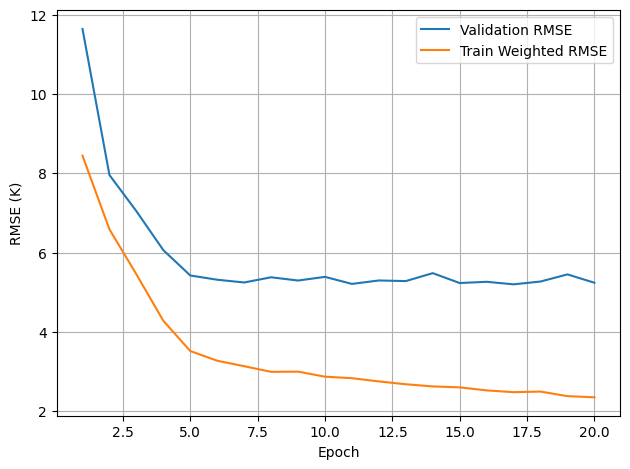

In [100]:
epochs = [h["epoch"] for h in history]

plt.plot(epochs, [h["rmse_K"] for h in history], label="Validation RMSE")
# plt.plot(epochs, [h["weighted_rmse_K"] for h in history], label="Weighted RMSE")
plt.plot(epochs, [h["train_weighted_rmse_K"] for h in history], label="Train Weighted RMSE")

plt.xlabel("Epoch")
plt.ylabel("RMSE (K)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [101]:
test_results = predict_loader(model, test_loader, info["stats"])
print(
    f"test case {cfg.test_case_id!r} | "
    f"wRMSE {test_results['metrics']['weighted_rmse_K']:.3f} K | "
    f"RMSE {test_results['metrics']['rmse_K']:.3f} K"
)

test case 6 | wRMSE 5.682 K | RMSE 5.682 K


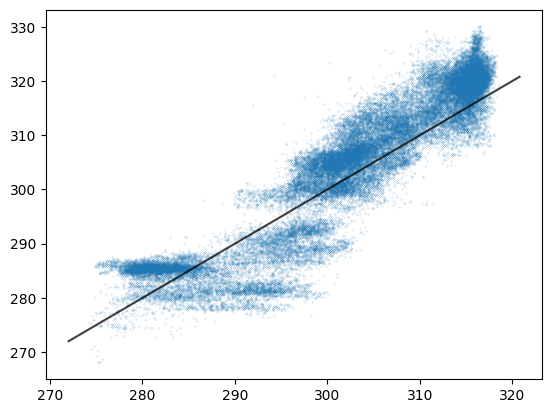

In [102]:
plt.scatter(test_results['predictions_K'], test_results['targets_K'], s=0.01, zorder=1)
lims = plt.xlim()
plt.plot(lims, lims, color='black', alpha=0.75, zorder=2)

plt.show()

In [103]:
test_index = 1000
print(test_results['predictions_K'][test_index])
print(test_results['targets_K'][test_index])

315.7483006232999
326.99337699801714


# Populate patches

### Populate definitions + method

In [ ]:
features = ['Blue', 'Green', 'Red', 'NIR']
target_col = 'LST_K'

In [ ]:
def populate_patches(input_df, input_patches, closest_date):

    # -------------------------
    # 1. Pivot
    # -------------------------
    df_pivot = input_df.pivot(
        index='time',
        columns='point_id',
        values=features + [target_col]
    ).sort_index()

    times = df_pivot.index.values
    point_ids = df_pivot.columns.levels[1].values

    # -------------------------
    # 2. Build feature tensor CORRECTLY
    # -------------------------
    # stack each feature explicitly to preserve alignment
    X = np.stack(
        [df_pivot[feat].values for feat in features],
        axis=-1
    )
    # shape: (T, P, F)

    y = df_pivot[target_col].values  # (T, P)

    # -------------------------
    # 3. point_id → index
    # -------------------------
    point_id_to_idx = {pid: i for i, pid in enumerate(point_ids)}

    all_patches_cubes = []
    all_patches_targets = []
    all_patches_times = []

    for patch in input_patches:
        patch = np.array(patch)
        flat_ids = patch.flatten()

        # map indices safely
        if not all(pid in point_id_to_idx for pid in flat_ids):
            all_patches_cubes.append([])
            all_patches_targets.append([])
            all_patches_times.append([])
            continue

        idxs = np.array([point_id_to_idx[pid] for pid in flat_ids])
        center_idx = point_id_to_idx[patch[2, 2]]

        # extract all times at once
        patch_data = X[:, idxs, :]   # (T, 25, F)

        # -------------------------
        # NEW: time filter
        # -------------------------
        time_mask = times <= np.datetime64(closest_date)

        # validity mask
        valid_mask = ~np.isnan(patch_data).any(axis=(1, 2))

        # combine both
        final_mask = valid_mask & time_mask

        if not final_mask.any():
            all_patches_cubes.append([])
            all_patches_targets.append([])
            all_patches_times.append([])
            continue

        valid_patch_data = patch_data[final_mask]
        valid_targets = y[final_mask, center_idx]
        valid_times = times[final_mask]

        # reshape to cubes
        cubes = valid_patch_data.reshape(-1, 5, 5, len(features))
        cubes = np.transpose(cubes, (0, 3, 1, 2))  # (Tv, F, 5, 5)

        all_patches_cubes.append(cubes)
        all_patches_targets.append(valid_targets)
        all_patches_times.append(valid_times)

    return all_patches_cubes, all_patches_targets, all_patches_times

In [ ]:
now = np.datetime64('now')

### Populate #0 patches

In [ ]:
cubes_0, targets_0, times_0 = populate_patches(predict_df, patches_0, now)

In [ ]:
len(cubes_0)

In [ ]:
len(patches_0)

In [ ]:
len(cubes_0[0])

In [ ]:
cubes_0[0][0]

In [ ]:
targets_0[0][0]

In [ ]:
times_0[0][0]

In [ ]:
min_len = min(len(patch) for patch in times_0)
print(min_len)

### Populate #2 patches

In [ ]:
cubes_2, targets_2, times_2 = populate_patches(train_df, patches_2, now)

In [ ]:
cubes_2[0][0]

In [ ]:
targets_2[0][0]

In [ ]:
times_2[0][0]

In [ ]:
min_len = min(len(patch) for patch in times_2)
print(min_len)

In [ ]:
len(cubes_2)

In [ ]:
len(patches_2)

### Populate Green Loop patches with 2021 as last

In [ ]:
cubes_trees_0, targets_trees_0, times_trees_0 = populate_patches(train_df, patches_2, target_date)

In [ ]:
cubes_trees_0[0][0]

In [ ]:
times_trees_0[0][0]

In [ ]:
min_len = min(len(patch) for patch in times_trees_0)
print(min_len)

In [ ]:
len(cubes_trees_0)

# Populate tree patches into arrays

In [ ]:
result_df = pd.read_csv('/content/drive/MyDrive/Year 2/Fall 2025/HONOR 3700/Data/0/Trees ML/0_radii_before_after_clean.csv')

In [ ]:
result_df = result_df.drop(columns=['Unnamed: 0'])

In [ ]:
result_df

In [ ]:
radii_to_grid_df.columns

In [ ]:
zonal_stats_df.columns

In [ ]:
def build_center_index(patches):
    return {patch[2, 2]: patch for patch in patches}


def build_zonal_lookup(zonal_stats_df):
    return zonal_stats_df.set_index("grid_id").to_dict("index")


def build_radii_to_grid_lookup(radii_to_grid_df):
    return radii_to_grid_df.set_index("radii_id")["grid_id"].to_dict()


def get_patch_by_center(center_value, center_index):
    """
    Fetch the 5x5 patch given a center value.
    Returns None if not found.
    """
    return center_index.get(center_value, None)

In [ ]:
center_index = build_center_index(patches_0)

In [ ]:
patch = get_patch_by_center(4713, center_index)

if patch is not None:
    print(patch)
    print(patch.shape)
else:
    print("Not found")

In [ ]:
result_df[result_df['radii_id'] == 1]

In [ ]:
BANDS = ["red", "green", "blue", "nir"]

In [ ]:
def build_result_array(
    result_df,
    radii_to_grid_df,
    zonal_stats_df,
    patches_tree_0
):
    radii_ids = []
    # --- Precompute lookups ---
    center_index = build_center_index(patches_tree_0)
    zonal_lookup = build_zonal_lookup(zonal_stats_df)
    radii_to_grid = build_radii_to_grid_lookup(radii_to_grid_df)

    unique_radii = result_df["radii_id"].unique()
    n = len(unique_radii)

    # Output: (N, 2, 4, 5, 5)
    output = np.zeros((n, 2, 4, 5, 5), dtype=float)

    for i, radii_id in enumerate(unique_radii):
        radii_ids.append(radii_id)
        # --- Step 1: get center grid_id ---
        center_grid_id = radii_to_grid[radii_id]

        # --- Step 2: get 5x5 patch of grid_ids ---
        patch = center_index.get(center_grid_id)
        if patch is None:
            continue  # or raise error if this should never happen

        # --- Step 3: subset result_df for this radii_id ---
        subset = result_df[result_df["radii_id"] == radii_id]
        subset_lookup = subset.set_index("grid_id").to_dict("index")

        # --- Step 4: fill cubes ---
        for r in range(5):
            for c in range(5):
                gid = patch[r, c]

                if gid in subset_lookup:
                    row = subset_lookup[gid]

                    for b_idx, band in enumerate(BANDS):
                        output[i, 0, b_idx, r, c] = row[f"before_{band}"]
                        output[i, 1, b_idx, r, c] = row[f"after_{band}"]

                else:
                    zonal = zonal_lookup[gid]

                    for b_idx, band in enumerate(BANDS):
                        val = zonal[f"{band}_mean"]
                        output[i, 0, b_idx, r, c] = val
                        output[i, 1, b_idx, r, c] = val

    return output, radii_ids

In [ ]:
output, radii_ids = build_result_array(
    result_df,
    radii_to_grid_df,
    zonal_stats_df,
    patches_0
)

In [ ]:
output.shape

In [ ]:
radii_ids[0:5]

In [ ]:
output[0][0]

In [ ]:
output[0][1]

# Transform tree patches

In [ ]:
landsat_blue_mean = predict_df['Blue'].mean()
landsat_red_mean = predict_df['Red'].mean()
landsat_green_mean = predict_df['Green'].mean()
landsat_nir_mean = predict_df['NIR'].mean()

landsat_blue_std = predict_df['Blue'].std()
landsat_red_std = predict_df['Red'].std()
landsat_green_std = predict_df['Green'].std()
landsat_nir_std = predict_df['NIR'].std()

In [ ]:
# take only the first item in the pair
data = output[:, 0, :, :, :]   # shape: (4099, 4, 5, 5)

# compute mean and std per band
means = data.mean(axis=(0, 2, 3))  # shape: (4,)
stds  = data.std(axis=(0, 2, 3))   # shape: (4,)

print("Means:", means)
print("Stds:", stds)

In [ ]:
naip_red_mean = means[0]
naip_blue_mean = means[1]
naip_green_mean = means[2]
naip_nir_mean = means[3]

naip_red_std = stds[0]
naip_blue_std = stds[1]
naip_green_std = stds[2]
naip_nir_std = stds[3]

In [ ]:
import numpy as np

# NAIP stats (from your computed means/stds)
naip_means = np.array([
    naip_red_mean,
    naip_green_mean,
    naip_blue_mean,
    naip_nir_mean
])

naip_stds = np.array([
    naip_red_std,
    naip_green_std,
    naip_blue_std,
    naip_nir_std
])

# Landsat stats (from dataframe)
landsat_means = np.array([
    landsat_red_mean,
    landsat_green_mean,
    landsat_blue_mean,
    landsat_nir_mean
])

landsat_stds = np.array([
    landsat_red_std,
    landsat_green_std,
    landsat_blue_std,
    landsat_nir_std
])

In [ ]:
# reshape to broadcast over (4099, 2, 4, 5, 5)
naip_means = naip_means.reshape(1, 1, 4, 1, 1)
naip_stds  = naip_stds.reshape(1, 1, 4, 1, 1)

landsat_means = landsat_means.reshape(1, 1, 4, 1, 1)
landsat_stds  = landsat_stds.reshape(1, 1, 4, 1, 1)

# apply transformation
output_normalized = (
    ((output - naip_stds) / naip_means) * landsat_stds
) + landsat_means

In [ ]:
output.shape

In [ ]:
output_normalized.shape

In [ ]:
output[0][0][0][0]

In [ ]:
output_normalized[0][0][0][0]

# Compute time embeddings

In [ ]:
data_dict[1]['metadata_df']

# Clip instead of sliding window

In [ ]:
features

In [ ]:
print(len(cubes_2), len(targets_2), len(time_embeddings_2))

In [ ]:
lengths = [len(item) for item in cubes_2]
min_len = min(lengths)
max_len = max(lengths)
print(min_len, max_len)

In [ ]:
WINDOW = 100
num_samples = len(cubes_2)

In [ ]:
E = len(time_embeddings_2[0][0])  # embedding size
print(E)

In [ ]:
F = len(features)
print(F)

In [ ]:
X_cubes = np.memmap(
    "X_cubes.dat",
    dtype="float32",
    mode="w+",
    shape=(num_samples, WINDOW, F, 5, 5)
)

X_embs = np.memmap(
    "X_embs.dat",
    dtype="float32",
    mode="w+",
    shape=(num_samples, WINDOW, E)
)

y = np.memmap(
    "y.dat",
    dtype="float32",
    mode="w+",
    shape=(num_samples,)
)

In [ ]:
print(len(cubes_0), len(targets_0), len(time_embeddings_0))

In [ ]:
num_samples_val = len(cubes_0)

In [ ]:
X_cubes_val = np.memmap(
    "X_cubes_val.dat",
    dtype="float32",
    mode="w+",
    shape=(num_samples_val, WINDOW, F, 5, 5)
)

X_embs_val = np.memmap(
    "X_embs_val.dat",
    dtype="float32",
    mode="w+",
    shape=(num_samples_val, WINDOW, E)
)

y_val = np.memmap(
    "y_val.dat",
    dtype="float32",
    mode="w+",
    shape=(num_samples_val,)
)

In [ ]:
len(final_output)

In [ ]:
num_samples_trees = len(final_output)

In [ ]:
X_cubes_before = np.memmap(
    "X_cubes_before.dat",
    dtype="float32",
    mode="w+",
    shape=(num_samples_trees, WINDOW, F, 5, 5)
)

X_cubes_after = np.memmap(
    "X_cubes_after.dat",
    dtype="float32",
    mode="w+",
    shape=(num_samples_trees, WINDOW, F, 5, 5)
)

X_embs_tree = np.memmap(
    "X_embs_tree.dat",
    dtype="float32",
    mode="w+",
    shape=(num_samples_trees, WINDOW, E)
)

y_tree = np.memmap(
    "y_tree.dat",
    dtype="float32",
    mode="w+",
    shape=(num_samples_trees,)
)

In [ ]:
def populate_data(num_populate,
                  cubes,
                  times,
                  targets,
                  cubes_memmap,
                  times_memmap,
                  targets_memmap):
    sample_idx = 0
    for seq_idx in range(num_populate):
        cubes_seq   = np.asarray(cubes[seq_idx], dtype=np.float32)   # (T,5,5,5)
        emb_seq     = np.asarray(times[seq_idx], dtype=np.float32)  # (T,E)
        targets_seq = np.asarray(targets[seq_idx], dtype=np.float32)

        T_seq = cubes_seq.shape[0]

        if T_seq < WINDOW:
            continue

        # --- take ONLY the last window ---
        cube_window = cubes_seq[-WINDOW:]   # (W, 5, 5, 5)
        emb_window  = emb_seq[-WINDOW:]     # (W, E)

        # add batch dimension (since memmap expects batches)
        cube_window = cube_window[np.newaxis, ...]  # (1, W, 5,5,5)
        emb_window  = emb_window[np.newaxis, ...]   # (1, W, E)

        # target aligned to final window
        target = targets_seq[-1]  # scalar
        target = np.array([target], dtype=np.float32)  # (1,)

        # --- write 1 sample ---
        cubes_memmap[sample_idx] = cube_window[0]
        times_memmap[sample_idx]  = emb_window[0]
        targets_memmap[sample_idx]       = target[0]

        sample_idx += 1

        # if (seq_idx % 100 == 0):
        #     print(f"Finished {seq_idx}, +1 sample (total {sample_idx})")

        cubes_memmap.flush()
        times_memmap.flush()
        targets_memmap.flush()

## Clip train

In [ ]:
populate_data(num_samples,
              cubes_2,
              time_embeddings_2,
              targets_2,
              X_cubes,
              X_embs,
              y)

In [ ]:
X_cubes.shape

In [ ]:
X_cubes[3586][0]

In [ ]:
X_embs[3586][0]

In [ ]:
y[3586]

In [ ]:
print(y.mean(), y.std())

## Clip val

In [ ]:
populate_data(num_samples_val,
              cubes_0,
              time_embeddings_0,
              targets_0,
              X_cubes_val,
              X_embs_val,
              y_val)

In [ ]:
X_cubes_val.shape

In [ ]:
X_cubes_val[5628][0]

In [ ]:
X_embs_val[5628][0]

In [ ]:
y_val[5628]

In [ ]:
print(y_val.mean(), y_val.std())

## Clip trees

In [ ]:
def populate_data_no_cubes(num_populate,
                  times,
                  targets,
                  times_memmap,
                  targets_memmap):
    sample_idx = 0

    for seq_idx in range(num_populate):
        emb_seq     = np.asarray(times[seq_idx], dtype=np.float32)   # (T, E)
        targets_seq = np.asarray(targets[seq_idx], dtype=np.float32)

        T_seq = emb_seq.shape[0]

        if T_seq < WINDOW:
            continue

        # take ONLY the last window
        emb_window = emb_seq[-WINDOW:]  # (W, E)

        # add batch dimension for memmap consistency
        emb_window = emb_window[np.newaxis, ...]  # (1, W, E)

        # target aligned to final timestep
        target = np.asarray([targets_seq[-1]], dtype=np.float32)  # (1,)

        # write sample
        times_memmap[sample_idx]  = emb_window[0]
        targets_memmap[sample_idx] = target[0]

        sample_idx += 1

        if seq_idx % 100 == 0:
        #     print(f"Finished {seq_idx}, +1 sample (total {sample_idx})")

            times_memmap.flush()
            targets_memmap.flush()
    times_memmap.flush()
    targets_memmap.flush()

In [ ]:
populate_data_no_cubes(
              num_samples_trees,
              time_embeddings_trees,
              targets_trees_0,
              X_embs_tree,
              y_tree)

In [ ]:
num_samples_trees_pairs = len(final_output) * 2

In [ ]:
final_output.shape

In [ ]:
def populate_data_pairs(num_populate,
                        cubes,          # (N, 2, T, 4, 5, 5)
                        cubes_memmap,
                        ):

    sample_idx = 0

    for seq_idx in range(num_populate):

        if seq_idx >= len(cubes):
            continue

        cubes_seq_all = np.asarray(cubes[seq_idx], dtype=np.float32)  # (2, T, 4, 5, 5)

        if cubes_seq_all.ndim != 5:
            continue

        T_seq = cubes_seq_all.shape[1]

        if T_seq < WINDOW:
            continue

        # --- loop over pairs ---
        for pair_idx in range(2):

            cubes_seq = cubes_seq_all[pair_idx]  # (T, 4, 5, 5)

            if cubes_seq.shape[0] != T_seq:
                continue

            cube_window = cubes_seq[-WINDOW:]  # (W, 4, 5, 5)

            # --- bounds check ---
            if sample_idx >= cubes_memmap.shape[0]:
                print(sample_idx, cubes_memmap.shape[0])
                raise IndexError("Memmap index out of bounds")

            cubes_memmap[sample_idx] = cube_window

            sample_idx += 1

        # periodic flush
        if seq_idx % 100 == 0:
            cubes_memmap.flush()

    # final flush
    cubes_memmap.flush()

    print(f"Total samples written: {sample_idx}")

In [ ]:
def populate_data_split_pairs(num_populate,
                        cubes,              # (N, 2, T, 4, 5, 5)
                        before_memmap,      # (N, WINDOW, 4, 5, 5)
                        after_memmap,       # (N, WINDOW, 4, 5, 5)
                        ):

    written = 0

    for seq_idx in range(num_populate):

        if seq_idx >= len(cubes):
            continue

        cubes_seq_all = np.asarray(cubes[seq_idx], dtype=np.float32)  # (2, T, 4, 5, 5)

        # sanity check
        if cubes_seq_all.ndim != 5 or cubes_seq_all.shape[0] != 2:
            continue

        T_seq = cubes_seq_all.shape[1]

        if T_seq < WINDOW:
            continue

        # extract before/after
        before_seq = cubes_seq_all[0]  # (T, 4, 5, 5)
        after_seq  = cubes_seq_all[1]  # (T, 4, 5, 5)

        # final window
        before_window = before_seq[-WINDOW:]  # (WINDOW, 4, 5, 5)
        after_window  = after_seq[-WINDOW:]   # (WINDOW, 4, 5, 5)

        # bounds check
        if seq_idx >= before_memmap.shape[0] or seq_idx >= after_memmap.shape[0]:
            raise IndexError(f"Memmap index out of bounds at {seq_idx}")

        before_memmap[seq_idx] = before_window
        after_memmap[seq_idx]  = after_window

        written += 1

        # periodic flush
        if seq_idx % 100 == 0:
            before_memmap.flush()
            after_memmap.flush()

    # final flush
    before_memmap.flush()
    after_memmap.flush()

    print(f"Total samples written: {written}")

In [ ]:
num_samples_trees

In [ ]:
populate_data_split_pairs(num_samples_trees,
              final_output,
              X_cubes_before,
              X_cubes_after
              )

In [ ]:
X_cubes_before.shape

In [ ]:
X_cubes_after.shape

In [ ]:
X_cubes_before[2186][99][0]

In [ ]:
X_cubes_after[2186][99][0]

In [ ]:
time_embeddings_trees[1000][0]

In [ ]:
X_embs_tree[1000][0]

In [ ]:
y_tree[1000]

In [ ]:
print(y_tree.mean(), y_tree.std())

# Construct X and y datasets

In [ ]:
num_samples

In [ ]:
num_samples_val

In [ ]:
num_samples_trees

In [ ]:
NUM_SAMPLES = num_samples

In [ ]:
WINDOW

In [ ]:
# -----------------------------
# Config
# -----------------------------
CUBE_CHANNELS = 4
GRID_H = 5
GRID_W = 5
E = 6  # temporal encoding dimension

SUBSET_FRACTION = 1.0
TRAIN_FRACTION = 0.8

BATCH_SIZE = 8
NUM_EPOCHS = 20
LR = 3e-4
WEIGHT_DECAY = 0
NUM_WORKERS = 4
MAX_GRAD_NORM = 1.0
SEED = 1024
ACCUM_STEPS = 1
USE_AMP = False
MAX_GRAD_NORM = None   # turn clipping off until tiny-set overfit works

In [ ]:
X_cubes_read = np.memmap(
    "X_cubes.dat",
    dtype="float32",
    mode="r",
    shape=(num_samples, WINDOW, F, 5, 5)
)

X_embs_read = np.memmap(
    "X_embs.dat",
    dtype="float32",
    mode="r",
    shape=(num_samples, WINDOW, E)
)

y_read = np.memmap(
    "y.dat",
    dtype="float32",
    mode="r",
    shape=(num_samples,)
)

In [ ]:
X_cubes_predict = np.memmap(
    "X_cubes_val.dat",
    dtype="float32",
    mode="r",
    shape=(num_samples_val, WINDOW, F, 5, 5)
)

X_embs_predict = np.memmap(
    "X_embs_val.dat",
    dtype="float32",
    mode="r",
    shape=(num_samples_val, WINDOW, E)
)

y_predict = np.memmap(
    "y_val.dat",
    dtype="float32",
    mode="r",
    shape=(num_samples_val,)
)

In [ ]:
X_cubes.shape

In [ ]:
X_embs.shape

In [ ]:
y.shape

In [ ]:
final_output.shape

In [ ]:
X_embs_tree.shape

In [ ]:
y_tree.shape

In [ ]:
num_samples_trees

In [ ]:
X_cubes_before = np.memmap(
    "X_cubes_before.dat",
    dtype="float32",
    mode="r",
    shape=(num_samples_trees, WINDOW, F, 5, 5)
)

X_cubes_after = np.memmap(
    "X_cubes_after.dat",
    dtype="float32",
    mode="r",
    shape=(num_samples_trees, WINDOW, F, 5, 5)
)

X_embs_tree = np.memmap(
    "X_embs_tree.dat",
    dtype="float32",
    mode="r",
    shape=(num_samples_trees, WINDOW, E)
)

y_tree = np.memmap(
    "y_tree.dat",
    dtype="float32",
    mode="r",
    shape=(num_samples_trees,)
)

# Hyperparameters

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SAVE_PATH = "/content/drive/MyDrive/Year 2/Fall 2025/HONOR 3700/Data/no_weights_complete.pt"

In [ ]:
DEVICE

# Weights / similarity scores

In [ ]:
rng = np.random.default_rng(SEED)

In [ ]:
random_weights = rng.random(size=num_samples)

In [ ]:
random_weights.shape

In [ ]:
random_weights.mean()

In [ ]:
random_weights = random_weights / (random_weights.mean() + 1e-8)

In [ ]:
random_weights.mean()

In [ ]:
weights_write = np.memmap(
    "weights.dat",
    dtype="float32",
    mode="w+",
    shape=(NUM_SAMPLES,)
)

In [ ]:
arr = np.full((3587, ), 1)

In [ ]:
weights_write[:] = random_weights[:]

In [ ]:
weights_write[num_samples - 1]

In [ ]:
weights_write.flush()

In [ ]:
weights = np.memmap(
    "weights.dat",
    dtype="float32",
    mode="r",
    shape=(NUM_SAMPLES,)
)

# Prep training

In [ ]:
# -----------------------------
# Reproducibility
# -----------------------------
def seed_everything(seed=1024):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


seed_everything(SEED)

In [ ]:
def weighted_mse(preds, y, w=None):
    per_sample = nn.functional.mse_loss(preds, y, reduction="none")
    if w is None:
        return per_sample.mean()
    return (per_sample * w).sum() / w.sum().clamp_min(1e-8)

In [ ]:
CUBE_LAYOUT = "TCHW"

In [ ]:
# -----------------------------
# Memmap Dataset
# -----------------------------
class MemmapSequenceDataset(Dataset):
    """
    Each item returns:
      x_cube: [T, C, H, W]   = [WINDOW, 5, 5, 5]
      x_emb:  [T, E]         = [WINDOW, 6]
      y:      scalar
    """

    def __init__(
        self,
        x_cubes_path,
        x_embs_path,
        y_path,
        indices,
        num_samples,
        window,
        emb_dim,
        cube_channels=5,
        grid_h=5,
        grid_w=5,
        weights_path=None,
        y_mean=None,
        y_std=None,
        cube_mean=None,
        cube_std=None,
        emb_mean=None,
        emb_std=None,
        cube_layout="TCHW",
    ):
        self.x_cubes_path = x_cubes_path
        self.x_embs_path = x_embs_path
        self.y_path = y_path

        self.indices = np.asarray(indices, dtype=np.int64)
        self.num_samples = num_samples
        self.window = window
        self.emb_dim = emb_dim
        self.cube_channels = cube_channels
        self.grid_h = grid_h
        self.grid_w = grid_w

        self._x_cubes = None
        self._x_embs = None
        self._y = None
        self.weights_path = weights_path
        self._weights = None

        self.y_mean = y_mean
        self.y_std = y_std
        self.cube_mean = cube_mean
        self.cube_std = cube_std
        self.emb_mean = emb_mean
        self.emb_std = emb_std

        self.cube_layout = cube_layout
        assert self.cube_layout in {"TCHW", "THWC"}

    def _lazy_open(self):
        if self._x_cubes is None:
            self._x_cubes = np.memmap(
                self.x_cubes_path,
                dtype="float32",
                mode="r",
                shape=(self.num_samples, self.window, self.cube_channels, self.grid_h, self.grid_w),
            )
        if self._x_embs is None:
            self._x_embs = np.memmap(
                self.x_embs_path,
                dtype="float32",
                mode="r",
                shape=(self.num_samples, self.window, self.emb_dim),
            )
        if self._y is None:
            self._y = np.memmap(
                self.y_path,
                dtype="float32",
                mode="r",
                shape=(self.num_samples,),
            )
        if self.weights_path is not None and self._weights is None:
            self._weights = np.memmap(
                self.weights_path,
                dtype="float32",
                mode="r",
                shape=(self.num_samples,),
            )


    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        self._lazy_open()

        sample_idx = int(self.indices[idx])

        # DO NOT copy unnecessarily
        x_cube = self._x_cubes[sample_idx]
        x_emb = self._x_embs[sample_idx]
        y = self._y[sample_idx]

        if self._weights is not None:
            w = float(self._weights[sample_idx])
        else:
            w = 1.0

        # Make writable safely (small cost, avoids warning)
        x_cube = np.array(x_cube, dtype=np.float32, copy=True)
        x_emb = np.array(x_emb, dtype=np.float32, copy=True)
        y = float(y)

        # --- Normalize cube ---
        if self.cube_mean is not None:
            # cube_mean: [C]
            # reshape to broadcast over [T, C, H, W]
            x_cube = (x_cube - self.cube_mean[None, :, None, None]) / (self.cube_std[None, :, None, None] + 1e-8)

        # --- Normalize embeddings ---
        if self.emb_mean is not None:
            # emb_mean: [E]
            x_emb = (x_emb - self.emb_mean[None, :]) / (self.emb_std[None, :] + 1e-8)

        if self.y_mean is not None:
            y = (y - self.y_mean) / (self.y_std + 1e-8)

        return (
            torch.from_numpy(x_cube),
            torch.from_numpy(x_emb),
            torch.tensor(y, dtype=torch.float32),
            torch.tensor(w, dtype=torch.float32),
        )

In [ ]:
# -----------------------------
# Model
# -----------------------------
class SpatialCubeEncoder(nn.Module):
    """
    Encodes each time step's cube independently.

    Input per sample:
      x_cube: [B, T, C, H, W]

    For each time step:
      - treat each of the 25 grid positions as a token
      - each token has 5 feature values
      - apply a Transformer encoder over those 25 tokens
      - return one vector per time step
    """

    def __init__(
        self,
        in_channels=4,
        d_model=64,
        nhead=4,
        num_layers=2,
        dropout=0,
        grid_h=5,
        grid_w=5,
    ):
        super().__init__()
        self.grid_h = grid_h
        self.grid_w = grid_w
        self.num_tokens = grid_h * grid_w
        self.center_idx = (grid_h // 2) * grid_w + (grid_w // 2)

        self.token_proj = nn.Linear(in_channels, d_model)
        # self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_tokens + 1, d_model))

        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv2d(32, in_channels, kernel_size=3, padding=1),
        )

        layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=4 * d_model,
            dropout=dropout,
            batch_first=True,
            norm_first=True,
            activation="gelu",
        )
        self.encoder = nn.TransformerEncoder(
            layer,
            num_layers=num_layers,
            enable_nested_tensor=False)

        self.norm = nn.LayerNorm(d_model)

        self.out = nn.Sequential(
            nn.LayerNorm(2 * d_model),
            nn.Linear(2 * d_model, d_model),
            nn.GELU(),
            nn.LayerNorm(d_model),
        )

        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.xavier_uniform_(self.token_proj.weight)
        nn.init.zeros_(self.token_proj.bias)

    def forward(self, x_cube):
        """
        x_cube: [B, T, C, H, W]
        returns: [B, T, d_model]
        """
        B, T, C, H, W = x_cube.shape
        x = x_cube.permute(0, 1, 3, 4, 2).reshape(B * T, H * W, C)  # [B*T, 25, C]
        x = self.token_proj(x)
        x = x + self.pos_embed[:, :x.size(1), :]
        x = self.encoder(x)

        center = x[:, self.center_idx, :]
        context = x.mean(dim=1)

        x = self.out(torch.cat([center, context], dim=-1))
        return x.view(B, T, -1)


In [ ]:
class TimeSeriesViTRegressor(nn.Module):
    """
    Hierarchical ViT-style model:
      1) spatial transformer over each 5x5 cube
      2) temporal transformer over the WINDOW timestamps
      3) regression head
    """

    def __init__(
        self,
        cube_channels=4,
        emb_dim=6,
        grid_h=5,
        grid_w=5,
        seq_len=WINDOW,
        d_model=64,
        spatial_heads=4,
        spatial_layers=1,
        temporal_heads=4,
        temporal_layers=2,
        dropout=0,
    ):
        super().__init__()
        self.grid_h = grid_h
        self.grid_w = grid_w

        self.spatial_encoder = SpatialCubeEncoder(
            in_channels=cube_channels,
            d_model=d_model,
            nhead=spatial_heads,
            num_layers=spatial_layers,
            dropout=dropout,
            grid_h=grid_h,
            grid_w=grid_w,
        )

        self.temporal_proj = nn.Sequential(
            nn.Linear(emb_dim, d_model),
            nn.GELU(),
            nn.Linear(d_model, d_model),
        )

        self.center_proj = nn.Sequential(
            nn.Linear(cube_channels + emb_dim, d_model),
            nn.GELU(),
            nn.Linear(d_model, d_model),
        )

        self.fuse_norm = nn.LayerNorm(d_model)
        self.temporal_pos_embed = nn.Parameter(torch.zeros(1, seq_len, d_model))

        temporal_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=temporal_heads,
            dim_feedforward=4 * d_model,
            dropout=dropout,
            batch_first=True,
            norm_first=True,
            activation="gelu",
        )
        self.temporal_encoder = nn.TransformerEncoder(temporal_layer, num_layers=temporal_layers)

        self.attn_pool = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 1),
        )

        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Linear(d_model, 1),
        )

        nn.init.trunc_normal_(self.temporal_pos_embed, std=0.02)

    def forward(self, x_cube, x_emb):
        # x_cube: [B, T, C, H, W]
        # x_emb:  [B, T, E]
        spatial = self.spatial_encoder(x_cube)       # [B, T, D]
        time_feat = self.temporal_proj(x_emb)        # [B, T, D]

        center = x_cube[:, :, :, self.grid_h // 2, self.grid_w // 2]   # [B, T, C]
        center = self.center_proj(torch.cat([center, x_emb], dim=-1))  # [B, T, D]

        x = self.fuse_norm(spatial + time_feat + center)
        x = x + self.temporal_pos_embed[:, :x.size(1), :]
        x = self.temporal_encoder(x)

        attn = torch.softmax(self.attn_pool(x), dim=1)
        x = (attn * x).sum(dim=1)

        return self.head(x).squeeze(-1)

In [ ]:
# -----------------------------
# Train / Eval loops
# -----------------------------
def train_one_epoch(model, loader, optimizer, criterion, scaler, device, use_amp=False, max_grad_norm=None):
    model.train()
    running_loss = 0.0
    optimizer.zero_grad(set_to_none=True)

    for step, (x_cube, x_emb, y, w) in enumerate(loader, start=1):
        x_cube = x_cube.to(device, non_blocking=True)
        x_emb = x_emb.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        w = w.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda', enabled=(device.type == "cuda")):
            preds = model(x_cube, x_emb)
            # per_sample_loss = criterion(preds, y)
            # weighted_loss = per_sample_loss * w
            raw_loss = weighted_mse(preds, y)   # ignore w until you have real weights
            # loss = weighted_loss.mean() / ACCUM_STEPS
            loss = raw_loss / ACCUM_STEPS

        scaler.scale(loss).backward()

        if step % ACCUM_STEPS == 0 or step == len(loader):
            scaler.unscale_(optimizer)
            if max_grad_norm is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        running_loss += loss.item() * x_cube.size(0)

    return running_loss / len(loader.dataset)

In [ ]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0

    for x_cube, x_emb, y, w in loader:
        x_cube = x_cube.to(device, non_blocking=True)
        x_emb = x_emb.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        # w = w.to(device, non_blocking=True)

        preds = model(x_cube, x_emb)
        # per_sample_loss = criterion(preds, y)
        # weighted_loss = per_sample_loss * w
        # loss = weighted_loss.mean()
        loss = weighted_mse(preds, y)

        running_loss += loss.item() * x_cube.size(0)

    return running_loss / len(loader.dataset)

# Train

In [ ]:
# File paths
X_CUBES_PATH = "X_cubes.dat"
X_EMBS_PATH = "X_embs.dat"
Y_PATH = "y.dat"

# Build subset indices
subset_size = int(num_samples * SUBSET_FRACTION)
rng = np.random.default_rng(SEED)
selected_indices = rng.choice(num_samples, size=subset_size, replace=False)
rng.shuffle(selected_indices)

# Train/val split
n_train = int(len(selected_indices) * TRAIN_FRACTION)
train_indices = selected_indices[:n_train]
val_indices = selected_indices[n_train:]

print("Train and val split done")

In [ ]:
# File paths
X_CUBES_PREDICT_PATH = "X_cubes_val.dat"
X_EMBS_PREDICT_PATH = "X_embs_val.dat"
Y_PREDICT_PATH = "y_val.dat"

# Build subset indices
subset_size_predict = int(num_samples_val * SUBSET_FRACTION)
# rng = np.random.default_rng(SEED)
# selected_indices = rng.choice(NUM_SAMPLES, size=subset_size, replace=False)
# rng.shuffle(selected_indices)
selected_indices_predict = np.arange(num_samples_val)

print("Predict set done")

In [ ]:
# File paths
X_CUBES_BEFORE_PATH = "X_cubes_before.dat"
X_CUBES_AFTER_PATH = "X_cubes_after.dat"
X_EMBS_TREE_PATH = "X_embs_tree.dat"
Y_TREE_PATH = "y_tree.dat"

# Build subset indices
subset_size_tree = int(num_samples_trees * SUBSET_FRACTION)
# rng = np.random.default_rng(SEED)
# selected_indices = rng.choice(NUM_SAMPLES, size=subset_size, replace=False)
# rng.shuffle(selected_indices)
selected_indices_tree = np.arange(num_samples_trees)

print("Tree set done")

## Compute normalization stats





In [ ]:
# -----------------------------
# Compute normalization stats (TRAIN ONLY, labels)
# -----------------------------
y_memmap = np.memmap(
    Y_PATH,
    dtype="float32",
    mode="r",
    shape=(NUM_SAMPLES,)
)

train_y = y_memmap[train_indices]

y_mean = float(train_y.mean())
y_std = float(train_y.std())

print(f"y_mean={y_mean:.4f}, y_std={y_std:.4f}")

In [ ]:
# -----------------------------
# Compute normalization stats (TRAIN ONLY, features)
# -----------------------------
cube_subset = X_cubes_read[train_indices]
# Move channel to front for convenience
# [N, T, C, H, W] -> [C, N, T, H, W]
cube_subset = np.transpose(cube_subset, (2, 0, 1, 3, 4))

if CUBE_LAYOUT == "THWC":
    cube_subset = np.transpose(cube_subset, (0, 1, 4, 2, 3))  # [N,T,H,W,C] -> [N,T,C,H,W]

cube_mean = cube_subset.mean(axis=(1, 2, 3, 4))  # shape: [C]
cube_std  = cube_subset.std(axis=(1, 2, 3, 4))   # shape: [C]

# Do the same for embeddings
emb_subset = X_embs_read[train_indices]  # [N, T, E]

emb_mean = emb_subset.mean(axis=(0, 1))  # [E]
emb_std  = emb_subset.std(axis=(0, 1))   # [E]

In [ ]:
print(f"cube_mean={cube_mean}")
print(f"cube_std={cube_std}")
print(f"emb_mean={emb_mean}")
print(f"emb_std={emb_std}")

## Create datasets

In [ ]:
train_ds = MemmapSequenceDataset(
    x_cubes_path=X_CUBES_PATH,
    x_embs_path=X_EMBS_PATH,
    y_path=Y_PATH,
    indices=train_indices,
    num_samples=NUM_SAMPLES,
    window=WINDOW,
    emb_dim=E,
    cube_channels=CUBE_CHANNELS,
    grid_h=GRID_H,
    grid_w=GRID_W,
    y_mean=y_mean,
    y_std=y_std,
    cube_mean=cube_mean,
    cube_std=cube_std,
    emb_mean=emb_mean,
    emb_std=emb_std,
)

val_ds = MemmapSequenceDataset(
    x_cubes_path=X_CUBES_PATH,
    x_embs_path=X_EMBS_PATH,
    y_path=Y_PATH,
    indices=val_indices,
    num_samples=NUM_SAMPLES,
    window=WINDOW,
    emb_dim=E,
    cube_channels=CUBE_CHANNELS,
    grid_h=GRID_H,
    grid_w=GRID_W,
    y_mean=y_mean,
    y_std=y_std,
    cube_mean=cube_mean,
    cube_std=cube_std,
    emb_mean=emb_mean,
    emb_std=emb_std,
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
    persistent_workers=(NUM_WORKERS > 0),
    drop_last=False,
    prefetch_factor=2 if NUM_WORKERS > 0 else None,
)

train_eval_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
    persistent_workers=False,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
    persistent_workers=(NUM_WORKERS > 0),
    drop_last=False,
)

print("Datasets and loaders")

In [ ]:
predict_ds = MemmapSequenceDataset(
    x_cubes_path=X_CUBES_PREDICT_PATH,
    x_embs_path=X_EMBS_PREDICT_PATH,
    y_path=Y_PREDICT_PATH,
    indices=selected_indices_predict,
    num_samples=num_samples_val,
    window=WINDOW,
    emb_dim=E,
    cube_channels=CUBE_CHANNELS,
    grid_h=GRID_H,
    grid_w=GRID_W,
    y_mean=y_mean,
    y_std=y_std,
    cube_mean=cube_mean,
    cube_std=cube_std,
    emb_mean=emb_mean,
    emb_std=emb_std,
)

In [ ]:
predict_loader = DataLoader(
    predict_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
    persistent_workers=(NUM_WORKERS > 0),
    drop_last=False,
)

In [ ]:
before_ds = MemmapSequenceDataset(
    x_cubes_path=X_CUBES_BEFORE_PATH,
    x_embs_path=X_EMBS_TREE_PATH,
    y_path=Y_TREE_PATH,
    indices=selected_indices_tree,
    num_samples=num_samples_trees,
    window=WINDOW,
    emb_dim=E,
    cube_channels=CUBE_CHANNELS,
    grid_h=GRID_H,
    grid_w=GRID_W,
    y_mean=y_mean,
    y_std=y_std,
    cube_mean=cube_mean,
    cube_std=cube_std,
    emb_mean=emb_mean,
    emb_std=emb_std,
)

In [ ]:
after_ds = MemmapSequenceDataset(
    x_cubes_path=X_CUBES_AFTER_PATH,
    x_embs_path=X_EMBS_TREE_PATH,
    y_path=Y_TREE_PATH,
    indices=selected_indices_tree,
    num_samples=num_samples_trees,
    window=WINDOW,
    emb_dim=E,
    cube_channels=CUBE_CHANNELS,
    grid_h=GRID_H,
    grid_w=GRID_W,
    y_mean=y_mean,
    y_std=y_std,
    cube_mean=cube_mean,
    cube_std=cube_std,
    emb_mean=emb_mean,
    emb_std=emb_std,
)

In [ ]:
before_loader = DataLoader(
    before_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
    persistent_workers=(NUM_WORKERS > 0),
    drop_last=False,
)

after_loader = DataLoader(
    after_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
    persistent_workers=(NUM_WORKERS > 0),
    drop_last=False,
)

In [ ]:
model = TimeSeriesViTRegressor(
    cube_channels=CUBE_CHANNELS,
    emb_dim=E,
    grid_h=GRID_H,
    grid_w=GRID_W,
    seq_len=WINDOW,
    d_model=128,
    spatial_heads=4,
    spatial_layers=2,
    temporal_heads=4,
    temporal_layers=4,
    dropout=0,
).to(DEVICE)

criterion = nn.MSELoss(reduction='none') # return vector instead of scalar
# criterion = nn.SmoothL1Loss(beta=1.0, reduction="none") # Huber Loss
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer, mode="min", factor=0.5, patience=2
# )
scaler = torch.amp.GradScaler('cuda', enabled=(DEVICE.type == "cuda"))

best_val_loss = float("inf")
best_state = None

print(f"Device: {DEVICE}")
print(f"Train samples: {len(train_ds)}")
print(f"Val samples:   {len(val_ds)}")

In [ ]:
# trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
# print(f"Trainable parameters: {trainable_params:,}")

In [ ]:
epochs = []
train_losses = []
val_losses = []

In [ ]:
DEVICE

In [ ]:
for epoch in range(1, NUM_EPOCHS + 1):
    epochs.append(epoch)

    # def train_one_epoch(model, loader, optimizer, criterion, scaler, device, use_amp=False, max_grad_norm=None):
    train_opt_loss = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        scaler=scaler,
        device=DEVICE,
        use_amp=USE_AMP,
        max_grad_norm=MAX_GRAD_NORM
    )

    # def evaluate(model, loader, criterion, device):
    train_eval_loss = evaluate(model, train_eval_loader, criterion, DEVICE)
    val_loss = evaluate(model, val_loader, criterion, DEVICE)

    train_losses.append(train_eval_loss)
    val_losses.append(val_loss)

    if epoch % 1 == 0:
        print(
            f"Epoch {epoch:04d}/{NUM_EPOCHS} | "
            f"train_opt={train_opt_loss:.6f} | "
            f"train_eval={train_eval_loss:.6f} | "
            f"val={val_loss:.6f}"
        )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(model.state_dict())
        torch.save(
            {
                "model_state_dict": best_state,
                "optimizer_state_dict": optimizer.state_dict(),
                "epoch": epoch,
                "val_loss": val_loss,
                "config": {
                    "WINDOW": WINDOW,
                    "E": E,
                    "CUBE_CHANNELS": CUBE_CHANNELS,
                    "GRID_H": GRID_H,
                    "GRID_W": GRID_W,
                },
            },
            SAVE_PATH,
        )
        # print(f"  Saved new best model to {SAVE_PATH}")

# print(f"Best validation loss: {best_val_loss:.6f}")

In [ ]:
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")
plt.legend()

# ax = plt.gca()
# ax.set_ylim([1E-1, 1])

plt.show()

#### Recreating the model

In [ ]:
model_recreate = TimeSeriesViTRegressor(
    cube_channels=CUBE_CHANNELS,
    emb_dim=E,
    grid_h=GRID_H,
    grid_w=GRID_W,
    seq_len=WINDOW,
    d_model=128,
    spatial_heads=4,
    spatial_layers=2,
    temporal_heads=4,
    temporal_layers=4,
    dropout=0,
).to(DEVICE)

In [ ]:
# Optional: load best weights back into the model
if best_state is not None:
    model_recreate.load_state_dict(best_state)

In [ ]:
model

# Load model in from .pt

In [ ]:
checkpoint = torch.load(SAVE_PATH, map_location=DEVICE, weights_only=True)

In [ ]:
model_recreate.load_state_dict(checkpoint["model_state_dict"])
model_recreate.eval()

In [ ]:
cfg = checkpoint["config"]

model_recreate = TimeSeriesViTRegressor(
    cube_channels=cfg["CUBE_CHANNELS"],
    emb_dim=cfg["E"],
    grid_h=cfg["GRID_H"],
    grid_w=cfg["GRID_W"],
    seq_len=cfg["WINDOW"],
    d_model=128,
    spatial_heads=4,
    spatial_layers=2,
    temporal_heads=4,
    temporal_layers=4,
    dropout=0.1,
).to(DEVICE)

# Predict on predict and validation dataset

In [ ]:
model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for batch_cubes, batch_embs, batch_y, batch_weights in val_loader:
        batch_cubes = batch_cubes.to(DEVICE)
        batch_embs = batch_embs.to(DEVICE)
        batch_y = batch_y.to(DEVICE)

        outputs = model(batch_cubes, batch_embs)

        all_preds.append(outputs.cpu())
        all_targets.append(batch_y.cpu())

# Concatenate all batches
preds = torch.cat(all_preds, dim=0)
y = torch.cat(all_targets, dim=0)

In [ ]:
model.eval()

predictions_0 = []
targets_0 = []

with torch.no_grad():
    for batch_cubes, batch_embs, batch_y, batch_weights in predict_loader:
        batch_cubes = batch_cubes.to(DEVICE)
        batch_embs = batch_embs.to(DEVICE)
        batch_y = batch_y.to(DEVICE)

        outputs = model(batch_cubes, batch_embs)

        predictions_0.append(outputs.cpu())
        targets_0.append(batch_y.cpu())

# Concatenate all batches
preds_all_0 = torch.cat(predictions_0, dim=0)
targets_all_0 = torch.cat(targets_0, dim=0)

In [ ]:
# Unnormalize
preds_unnorm = preds * y_std + y_mean
y_unnorm = y * y_std + y_mean

# print("Predictions:", preds_unnorm)
# print("Targets:    ", y_unnorm)

print(preds_unnorm.mean(), preds_unnorm.std())
print(y_unnorm.mean(), y_unnorm.std())

# Plot
x_plot = np.linspace(250, 350, 100)
y_plot = x_plot

In [ ]:
preds_unnorm

In [ ]:
y_unnorm

In [ ]:
y_unnorm.min()

In [ ]:
y_unnorm.max()

In [ ]:
plt.scatter(preds_unnorm.numpy(), y_unnorm.numpy(), alpha=0.5)
plt.plot(x_plot, y_plot, label='y = x', color='red')
plt.xlabel("Predictions")
plt.ylabel("Targets")
plt.legend()
plt.show()

In [ ]:
preds_fahrenheit = (preds_unnorm - 273.15) * 1.8 + 32
y_plot_fahrenheit = (y_unnorm - 273.15) * 1.8 + 32

In [ ]:
# Plot
x_plot_f = np.linspace(60, 90, 100)
y_plot_f = x_plot_f

In [ ]:
r2 = r2_score(y_plot_fahrenheit.numpy(), preds_fahrenheit.numpy())

In [ ]:
r2

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')

plt.figure(figsize=(6, 6))

plt.scatter(preds_fahrenheit.numpy(), y_plot_fahrenheit.numpy(), alpha=0.5, color='blue')
plt.plot(x_plot_f, y_plot_f, label=f'Line of equality', color='red')

plt.xlim(66, 84)

plt.xlabel("Predicted Temperatures (F)")
plt.ylabel("True Temperatures (F)")
plt.legend()
plt.show()

In [ ]:
plt.hist(y_unnorm.numpy(), bins=20)
plt.show()

In [ ]:
# Unnormalize
preds_unnorm_0 = preds_all_0 * y_std + y_mean
y_unnorm_0 = targets_all_0 * y_std + y_mean

# print("Predictions:", preds_unnorm)
# print("Targets:    ", y_unnorm)

print(preds_unnorm_0.mean(), preds_unnorm_0.std())
print(y_unnorm_0.mean(), y_unnorm_0.std())

# Plot
x_plot = np.linspace(250, 350, 100)
y_plot = x_plot

In [ ]:
preds_all_0.shape

In [ ]:
targets_all_0.shape

In [ ]:
x_plot_norm = np.linspace(-5, 5, 100)
y_plot_norm = x_plot_norm

In [ ]:
plt.scatter(preds_all_0.numpy(), targets_all_0.numpy(), alpha=0.5)
plt.plot(x_plot_norm, y_plot_norm, label='y = x', color='red')
plt.xlabel("Predictions")
plt.ylabel("Targets")
plt.legend()
plt.show()

In [ ]:
len(preds_unnorm_0)

In [ ]:
len(y_unnorm_0)

In [ ]:
len(patches_0)

In [ ]:
preds_unnorm_0[0]

In [ ]:
y_unnorm_0[0]

In [ ]:
data = []

In [ ]:
for i in range(len(patches_0)):
    center_value = patches_0[i][2][2]  # center of 5x5 array
    prediction = preds_unnorm_0[i].item()
    target = y_unnorm_0[i].item()

    data.append({
        "grid_id": center_value,
        "prediction": prediction,
        "target": target
    })

# Create DataFrame
grid_preds_df = pd.DataFrame(data)

In [ ]:
grid_preds_df

In [ ]:
grid_preds_df.to_csv("grid_preds.csv", index=False)

# Predict on before + Tree Analysis

In [ ]:
model.eval()

predictions_before = []

with torch.no_grad():
    for batch_cubes, batch_embs, _, batch_weights in before_loader:
        batch_cubes = batch_cubes.to(DEVICE)
        batch_embs = batch_embs.to(DEVICE)

        outputs = model(batch_cubes, batch_embs)

        predictions_before.append(outputs.cpu())

# Concatenate all batches
preds_all_before = torch.cat(predictions_before, dim=0)

In [ ]:
model.eval()

predictions_after = []

with torch.no_grad():
    for batch_cubes, batch_embs, _, batch_weights in after_loader:
        batch_cubes = batch_cubes.to(DEVICE)
        batch_embs = batch_embs.to(DEVICE)

        outputs = model(batch_cubes, batch_embs)

        predictions_after.append(outputs.cpu())

# Concatenate all batches
preds_all_after = torch.cat(predictions_after, dim=0)

In [ ]:
len(preds_all_before)

In [ ]:
len(preds_all_after)

In [ ]:
# Unnormalize
preds_before_unnorm = preds_all_before * y_std + y_mean
preds_after_unnorm = preds_all_after * y_std + y_mean

In [ ]:
preds_before_unnorm[100]

In [ ]:
preds_after_unnorm[100]

In [ ]:
len(valid_radii_ids)

In [ ]:
valid_radii_ids[0]

In [ ]:
valid_radii_df = radii_df[radii_df["radii_id"].isin(valid_radii_ids)]

In [ ]:
valid_radii_df

In [ ]:
valid_radii_df['diff'] = preds_before_unnorm - preds_after_unnorm

In [ ]:
valid_radii_df

In [ ]:
# DBH distribution
sns.histplot(valid_radii_df['DBH'], bins=50, kde=True)
plt.title('DBH Distribution')
plt.show()

In [ ]:
# diff distribution
sns.histplot(valid_radii_df['diff'], bins=50, kde=True)
plt.title('Temperature Change (diff) Distribution')
plt.show()

In [ ]:
sns.scatterplot(data=valid_radii_df, x='DBH', y='diff', alpha=0.3)
plt.title('DBH vs Temperature Change')
plt.show()

# With trend line
sns.regplot(data=valid_radii_df, x='DBH', y='diff', scatter_kws={'alpha':0.2})
plt.title('DBH vs Temperature Change (with trend)')
plt.show()

In [ ]:
top_species = valid_radii_df['SPP'].value_counts().head(10).index
df_top = valid_radii_df[valid_radii_df['SPP'].isin(top_species)]

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df_top, x='SPP', y='diff')
plt.xticks(rotation=45)
plt.title('Temperature Change by Species')
plt.show()

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df_top, x='SPP', y='DBH')
plt.xticks(rotation=45)
plt.title('DBH by Species')
plt.show()

In [ ]:
print(valid_radii_df[['DBH', 'diff']].corr())

In [ ]:
species_summary = valid_radii_df.groupby('SPP').agg({
    'DBH': ['mean', 'median', 'count'],
    'diff': ['mean', 'median']
}).sort_values(('diff', 'mean'), ascending=False)

print(species_summary.head(10))

In [ ]:
pivot = df_top.pivot_table(values='diff', index='SPP', aggfunc='mean')

sorted_pivot = pivot.sort_values(by='diff', ascending=False)

sns.heatmap(sorted_pivot, annot=True, cmap='coolwarm_r')
plt.title('Average Temperature Change by Species')
plt.show()

In [ ]:
import statsmodels.formula.api as smf

# Treat species as categorical
model_tree = smf.ols('diff ~ DBH + C(SPP)', data=valid_radii_df).fit()

print(model_tree.summary())

In [ ]:
coefs = model_tree.params.filter(like='C(SPP)')
coefs = coefs.sort_values()

coefs.plot(kind='barh', figsize=(8,10))

In [ ]:
valid_radii_df_copy = valid_radii_df.copy()

In [ ]:
model_dbh = smf.ols('diff ~ DBH', data=valid_radii_df_copy).fit()

valid_radii_df_copy['diff_resid'] = model_dbh.resid
top_species = valid_radii_df_copy['SPP'].value_counts().head(10).index
df_top = valid_radii_df_copy[valid_radii_df_copy['SPP'].isin(top_species)]

sns.boxplot(data=df_top, x='SPP', y='diff_resid')
plt.xticks(rotation=45)
plt.title('Species Effect (DBH Controlled)')
plt.show()

# Shap Analysis

In [ ]:
def collect_samples(loader, n_samples):
    cubes = []
    embs = []

    for x_cube, x_emb, _, _ in loader:
        cubes.append(x_cube)
        embs.append(x_emb)

        if sum(x.shape[0] for x in cubes) >= n_samples:
            break

    cubes = torch.cat(cubes, dim=0)[:n_samples]
    embs = torch.cat(embs, dim=0)[:n_samples]

    return cubes.to(device), embs.to(device)

In [ ]:
# Select small subsets (important for SHAP performance)
N_BACKGROUND = 50
N_SAMPLES = 100

TOTAL = N_BACKGROUND + N_SAMPLES

x_cube_all, x_emb_all = collect_samples(train_loader, TOTAL)

background_cube = x_cube_all[:N_BACKGROUND]
background_emb = x_emb_all[:N_BACKGROUND]

test_cube = x_cube_all[N_BACKGROUND:TOTAL]
test_emb = x_emb_all[N_BACKGROUND:TOTAL]

In [ ]:
cube_baseline = background_cube.mean(dim=0, keepdim=True)  # [1, T, C, H, W]

In [ ]:
print("x_cube_sample:", test_cube.shape)
print("background_cube:", background_cube.shape)
print("test_cube:", test_cube.shape)

In [ ]:
class RasterWrapper(torch.nn.Module):
    def __init__(self, model, x_cube, x_emb, baseline):
        super().__init__()
        self.model = model
        self.x_cube = x_cube
        self.x_emb = x_emb
        self.baseline = baseline

    def forward(self, band_mask):
        band_mask = torch.tensor(band_mask, dtype=torch.float32, device=self.x_cube.device)

        outputs = []

        for i in range(band_mask.shape[0]):
            x_cube = self.x_cube[i % len(self.x_cube)].clone()
            x_emb = self.x_emb[i % len(self.x_emb)].unsqueeze(0)

            mask = band_mask[i]

            for j in range(4):
                x_cube[:, j, :, :] = (
                    mask[j] * x_cube[:, j, :, :]
                    + (1 - mask[j]) * self.baseline[:, j, :, :]
                )

            out = self.model(x_cube.unsqueeze(0), x_emb)
            outputs.append(out.item())

        return np.array(outputs)

In [ ]:
raster_model = RasterWrapper(model, test_cube, test_emb, cube_baseline)

explainer = shap.KernelExplainer(
    raster_model,
    np.zeros((N_BACKGROUND, 4))  # baseline = all features ON
)

shap_values = explainer.shap_values(
    np.ones((N_SAMPLES, 4)),
    nsamples=200
)

In [ ]:
background_mask = np.ones((N_BACKGROUND, 4))
explainer = shap.KernelExplainer(raster_model, background_mask)

In [ ]:
shap_values = explainer.shap_values(
    np.zeros((N_SAMPLES, 4)),
    nsamples=200
)

In [ ]:
feature_names_raster = ['Blue', 'Green', 'Red', 'NIR']

importance_raster = np.mean(np.abs(shap_values), axis=0)

for name, val in zip(feature_names_raster, importance_raster):
    print(f"{name}: {val:.6f}")

In [ ]:
shap_values

In [ ]:
X_explain = np.ones((N_SAMPLES, 4))

In [ ]:
shap.summary_plot(
    shap_values,
    X_explain,
    feature_names=feature_names_raster,
    plot_type="dot"   # this is the classic beeswarm
)

In [ ]:
print(np.unique(shap_values, axis=0).shape)

In [ ]:
mask_all_on = np.ones((10, 4))
mask_blue_off = np.array([[0,1,1,1]] * 10)

out1 = raster_model(mask_all_on)
out2 = raster_model(mask_blue_off)

print("diff:", np.abs(out1 - out2).mean())

## Manually Improve tree visual

In [ ]:
data = """
                               DBH                   diff
                              mean median count      mean    median
SPP
Prunus cerasifera         9.500000    9.5    78  0.000332  0.000198
Fraxinus pennsylvanica   15.896226   13.0   106  0.000324  0.000153
Tilia cordata            15.052910   15.0   189  0.000286  0.000214
Gleditsia triacanthos    11.321033   10.0   271  0.000272  0.000092
Acer platanoides         12.752542   13.0   295  0.000272  0.000153
Zelkova serrata           8.689189    8.5    74  0.000230  0.000092
Fraxinus americana       12.676923    7.0    65  0.000194  0.000031
Koelreuteria paniculata   8.322581    7.0    93  0.000189  0.000061
Ulmus pumila             17.535714   18.5    56  0.000183  0.000000
Acer campestre            5.611111    6.5    36  0.000168  0.000061
"""

In [ ]:
# Use StringIO to simulate reading from a file
data_io = StringIO(data)

# Read the data using fixed-width formatting
df = pd.read_fwf(data_io, skiprows=1)

# Ensure the index is treated as strings before applying .str.strip()
df.index = df.index.astype(str).str.strip()  # Convert to string and strip extra spaces

# Set the index name
df.index.name = 'SPP'

# Display the DataFrame
print(df)

In [ ]:
df

In [ ]:
df.columns

In [ ]:
trees = df['Unnamed: 0'][2:12]

In [ ]:
trees = trees.values

In [ ]:
trees

In [ ]:
diff = df['diff'][2:12].values

In [ ]:
diff

In [ ]:
# Convert diff to numeric values
diff_values = np.array(diff, dtype=float)

# Map scientific names to common names
tree_names = [
    "Cherry Plum", "Green Ash", "Littleleaf Linden", "Honey Locust",
    "Norway Maple", "Japanese Zelkova", "White Ash", "Golden Rain Tree",
    "Siberian Elm", "Field Maple"
]

# Reshape data for vertical plotting
heatmap_data = diff_values.reshape(-1, 1)  # 10 rows and 1 column

# Plotting
plt.figure(figsize=(6, 10))  # Adjust figure size for vertical plot
sns.heatmap(heatmap_data, annot=True, fmt=".6f", cmap="Blues", cbar=False,
            yticklabels=tree_names, xticklabels=[], linewidths=0.5, annot_kws={"size": 12})

# Adding titles and labels
plt.title('Average Temperature Change by Species', fontsize=16)
plt.ylabel('Tree Common Name', fontsize=14)
plt.xlabel('Average Temperature Change (F°)', fontsize=14)
plt.xticks(rotation=0, fontsize=12)

# Display the plot
plt.tight_layout()
plt.show()

## Manually improve y=x visual

In [ ]:
preds_unnorm = torch.tensor([294.7507, 296.6019, 294.5652, 297.7119, 296.3309, 299.6476, 297.2599,
        299.9776, 296.0145, 293.5339, 297.4186, 294.5519, 295.4861, 295.6086,
        296.8364, 294.2731, 300.5819, 297.4433, 300.1646, 297.3561, 294.9128,
        292.4753, 295.0919, 299.4135, 296.9405, 299.0190, 299.8626, 299.6950,
        294.5245, 299.7116, 293.0045, 294.4109, 297.9915, 296.2491, 297.0178,
        293.4608, 297.9462, 296.2819, 296.4639, 300.4330, 297.1958, 296.2484,
        297.4729, 294.3038, 299.5190, 294.1743, 296.4955, 297.2093, 293.4543,
        299.1041, 294.2680, 298.8888, 295.3980, 296.1072, 296.6035, 296.7653,
        298.2326, 296.7818, 297.2308, 294.4108, 295.5540, 296.0214, 294.7556,
        298.2798, 295.5528, 296.5593, 298.0962, 297.5204, 298.4678, 299.8365,
        296.3847, 294.7503, 296.9663, 294.6712, 297.1630, 298.7138, 296.3089,
        300.5038, 296.6037, 300.4133, 299.7316, 299.5822, 298.3838, 295.3302,
        297.5019, 296.7379, 297.0543, 294.4309, 299.5239, 298.8886, 294.6006,
        300.0857, 293.3101, 295.2346, 295.3802, 299.2053, 293.5810, 293.1740,
        297.3379, 300.1039, 299.2092, 298.5229, 295.5670, 294.6164, 299.1379,
        292.5794, 298.0905, 298.2389, 300.3297, 300.2678, 297.5212, 299.4913,
        294.1200, 293.5965, 294.9438, 299.5648, 297.6114, 299.7213, 296.7238,
        297.4135, 296.1410, 297.6916, 298.5713, 299.1659, 296.3541, 298.0750,
        296.5002, 298.5743, 296.6191, 297.2762, 297.6244, 294.8992, 296.0224,
        296.4073, 294.6002, 297.0670, 299.7405, 295.0194, 299.3399, 294.7008,
        294.0616, 295.7085, 298.3748, 299.6836, 298.1008, 296.0443, 293.6432,
        294.7923, 301.2943, 297.1941, 296.4027, 298.0688, 298.8130, 298.0378,
        296.7447, 298.1469, 296.2324, 298.1201, 295.0693, 294.5768, 299.5408,
        296.9343, 293.6283, 298.4067, 300.0537, 294.6967, 295.0175, 295.4644,
        298.4882, 297.8055, 295.1065, 297.1845, 297.7071, 297.5224, 295.8727,
        294.3928, 298.8297, 295.7058, 298.8629, 295.3778, 296.1621, 297.3619,
        299.9836, 293.9102, 297.7313, 297.4741, 297.5670, 294.9366, 297.1759,
        296.5879, 293.6383, 297.0233, 296.6589, 300.3842, 298.7970, 297.7484,
        295.2019, 295.1942, 295.8504, 298.1070, 296.0696, 297.3343, 297.6083,
        297.0779, 298.6916, 294.7061, 299.5597, 296.3508, 297.4706, 297.7589,
        295.7502, 293.6747, 297.6173, 296.9476, 296.8565, 296.4911, 300.5001,
        296.9590, 293.7014, 298.6086, 293.6461, 296.1596, 297.1188, 293.7431,
        295.4135, 295.4780, 294.9102, 297.9886, 299.8043, 297.8342, 296.9083,
        299.6050, 299.5560, 297.0341, 296.4593, 294.1633, 296.7134, 297.1864,
        299.8774, 296.4457, 293.0046, 295.6819, 298.5512, 294.3384, 297.5413,
        294.0111, 297.6596, 294.6622, 294.9673, 298.8925, 297.0343, 294.7280,
        296.1896, 299.4577, 293.4722, 294.8628, 296.5476, 293.8123, 300.7623,
        297.7492, 294.7803, 293.9583, 298.4516, 297.2069, 295.8787, 298.5242,
        297.1819, 293.7771, 294.4133, 300.0968, 293.5688, 297.7760, 300.0222,
        297.9463, 299.5521, 293.7176, 294.6096, 298.0879, 297.6516, 296.4531,
        299.6537, 298.0399, 300.9933, 297.1665, 300.4946, 297.9964, 296.0726,
        295.9960, 295.5714, 297.0491, 300.0613, 293.8190, 296.6695, 298.9428,
        295.0955, 294.5691, 295.7210, 296.3853, 297.5792, 294.9802, 296.6474,
        299.4610, 298.0168, 295.7363, 297.4600, 295.3996, 297.5168, 295.9746,
        297.2411, 297.1563, 299.5256, 295.1132, 297.2874, 296.1183, 300.1546,
        297.5360, 296.3634, 296.2160, 299.0366, 296.1554, 300.8787, 294.8153,
        297.1078, 296.8858, 296.7762, 300.1650, 297.9828, 295.6076, 296.8494,
        296.4464, 295.6685, 297.7400, 298.1704, 296.0308, 294.9142, 298.0251,
        297.3441, 295.2446, 295.5033, 297.9606, 295.7980, 296.8477, 293.4062,
        301.0867, 297.7698, 299.0137, 296.9111, 299.4541, 295.2271, 297.3490,
        297.7765, 297.6196, 293.7717, 297.1818, 295.8363, 299.5132, 300.5380,
        296.8820, 299.8406, 294.3110, 295.8570, 298.0497, 295.5246, 296.8236,
        299.9879, 294.9993, 296.5039, 297.7931, 300.0815, 298.5635, 297.0372,
        297.2875, 297.2456, 295.1347, 296.0266, 297.5398, 293.5122, 297.8319,
        299.3787, 294.8234, 297.2476, 299.7699, 295.2408, 292.7068, 295.6629,
        297.7418, 300.2245, 297.2420, 299.7912, 296.2285, 299.5057, 294.4713,
        295.7811, 299.9091, 295.2336, 299.6179, 296.9087, 298.6679, 295.9690,
        295.4603, 297.3111, 298.3701, 299.0649, 296.7255, 296.7870, 298.9558,
        300.4229, 298.3925, 296.7154, 297.5239, 297.9934, 296.7928, 300.2096,
        299.0546, 297.3701, 297.0881, 299.4336, 295.5641, 296.6752, 297.7224,
        297.2809, 297.3929, 299.6538, 294.8758, 300.9228, 297.0115, 294.1470,
        295.1328, 297.7914, 298.7171, 298.1473, 296.3312, 298.4358, 293.6812,
        294.7197, 293.9037, 296.9352, 296.5631, 296.2399, 297.1321, 296.9532,
        296.4916, 300.1656, 298.4278, 295.9075, 296.1221, 294.2315, 294.0403,
        297.4035, 297.0404, 296.5224, 299.5020, 296.4365, 296.4473, 298.2498,
        294.3897, 300.8895, 298.6735, 298.9193, 294.6365, 295.6960, 299.8002,
        298.2797, 294.8460, 294.4368, 296.2061, 294.0626, 296.7852, 299.1583,
        296.4608, 295.1283, 299.2381, 297.4897, 297.3786, 295.0814, 294.6461,
        296.8152, 296.2914, 294.2015, 296.1078, 297.0053, 297.9200, 294.2405,
        296.0155, 297.5692, 294.6060, 295.2283, 300.0112, 297.3456, 295.7384,
        297.3344, 294.2711, 296.3999, 293.8871, 297.2637, 296.7962, 294.1617,
        299.3282, 298.5613, 300.4791, 294.1920, 296.3267, 295.2780, 299.7372,
        294.8161, 297.6534, 293.4237, 297.1714, 294.4976, 299.7589, 300.5674,
        297.7322, 299.2420, 299.5847, 298.3414, 298.8369, 296.2178, 299.5815,
        294.7778, 295.4715, 296.9297, 296.8731, 297.2031, 296.3614, 298.3275,
        295.8221, 295.5801, 295.0924, 297.0412, 299.9297, 295.1926, 294.9890,
        298.0285, 297.3012, 297.4872, 298.4454, 295.1455, 296.0381, 292.9600,
        299.5180, 297.4716, 296.7519, 299.3435, 296.1806, 294.9251, 296.1093,
        300.0642, 296.4698, 299.7862, 296.7103, 297.3063, 300.4940, 294.0807,
        298.6458, 296.7876, 295.2935, 297.0698, 298.3859, 295.3464, 297.0068,
        294.4165, 300.7569, 297.1435, 297.9938, 297.3145, 294.7646, 293.7715,
        293.5870, 298.3569, 295.9051, 298.2701, 294.1749, 297.4444, 293.9511,
        297.7240, 297.3318, 293.0762, 297.6752, 300.0562, 296.4662, 297.7810,
        297.4611, 293.5255, 293.5765, 298.6037, 294.9070, 294.6262, 296.9489,
        295.4363, 300.1796, 299.3375, 295.9817, 296.4479, 299.0882, 296.2646,
        298.3287, 296.6477, 295.7881, 293.6489, 297.7086, 297.6715, 294.6913,
        295.5450, 299.3403, 294.8502, 296.6186, 299.4090, 300.0594, 299.7621,
        298.8298, 298.0446, 294.6737, 299.8033, 294.2237, 292.5161, 297.4819,
        297.2828, 296.9039, 298.6322, 299.8932, 295.3236, 298.3879, 298.0159,
        295.5467, 296.9298, 292.7316, 298.3181, 295.9134, 296.6001, 295.9311,
        297.7782, 296.3508, 295.1714, 300.1435, 295.8568, 298.0916, 297.8065,
        297.7837, 295.3489, 299.7269, 293.6471, 299.7718, 297.6528, 297.7560,
        293.8987, 296.6857, 296.6921, 299.4704, 297.2138, 297.9294, 298.9625,
        298.3586, 299.3762, 297.2274, 294.4627, 294.9040, 297.4782, 300.0683,
        297.7971, 295.5031, 295.2084, 297.3454, 298.5442, 300.5210, 294.9618,
        299.8842, 298.0179, 295.4084, 295.2540, 298.6272, 296.8380, 292.6769,
        299.0291, 296.1728, 297.9988, 299.3026, 296.2441, 294.5614, 298.6628,
        294.7459, 293.0370, 296.6389, 296.1346, 297.6979, 298.4521, 292.4278,
        296.3662, 295.7740, 298.2115, 299.6914, 296.5692, 296.9812, 300.4814,
        296.8436, 296.0017, 298.5587, 297.3181, 295.2514, 294.2508, 295.9032,
        295.9811, 294.9172, 296.3576, 297.4414, 298.0845, 296.4384, 297.2839,
        295.6343, 295.5511, 295.5982, 296.9592, 294.6360, 300.0062, 296.9197,
        298.4705, 295.1382, 296.2069, 297.1775, 296.3577, 293.6149, 297.2499,
        294.5683, 300.4460, 297.7963, 294.1447, 299.9570, 295.5917, 293.0052,
        298.1022, 298.6225, 294.7267, 297.0316, 294.4202, 299.2790, 299.1038,
        298.3268, 294.4812, 296.9696, 296.3156, 299.9049, 295.0954, 293.8953,
        299.9019, 296.9974, 298.9225, 294.5443, 298.2816, 297.2016, 300.2283,
        295.1487, 295.6702, 294.8208, 299.9175, 297.7397, 294.2673, 296.3129,
        297.5144, 299.5436, 295.8557, 297.3867, 295.8568, 298.6028, 300.0981,
        295.1863, 298.1247, 299.8365, 296.3177, 299.4365, 299.3505, 296.4422])

In [ ]:
y_unnorm = torch.tensor([294.7170, 296.7508, 294.1633, 297.2566, 296.2380, 299.0067, 297.3387,
        299.4954, 295.8860, 293.7053, 296.6756, 294.9084, 295.2981, 295.4929,
        296.1458, 294.4641, 300.7088, 296.9969, 300.6336, 297.5335, 294.7581,
        290.7692, 295.2161, 299.1878, 297.4925, 298.6033, 299.6800, 299.9774,
        294.5735, 299.8270, 292.8440, 293.8591, 298.3025, 296.2415, 296.5901,
        292.8029, 297.2669, 296.4089, 296.5046, 300.4251, 297.0994, 296.2551,
        297.4788, 293.7121, 299.2186, 294.1736, 295.6023, 296.9490, 293.9001,
        299.6834, 293.8625, 299.2322, 295.4519, 295.7253, 296.5354, 296.9114,
        298.1180, 296.4670, 296.5251, 294.3889, 295.8826, 296.4055, 293.9070,
        297.9265, 295.6604, 296.8533, 298.2410, 297.7078, 298.0496, 300.3841,
        296.8260, 294.9255, 296.6277, 294.4333, 297.4480, 298.5247, 296.4294,
        300.9105, 296.9182, 300.3294, 299.8304, 299.1400, 298.5281, 294.7512,
        297.6702, 296.6892, 297.3181, 294.0197, 299.3177, 299.4236, 294.6589,
        299.6937, 292.8200, 295.3596, 295.1033, 299.7381, 293.5549, 292.6560,
        297.1951, 300.1038, 298.9007, 298.6546, 295.6912, 294.0847, 298.7469,
        290.7726, 297.8069, 298.5076, 300.5755, 300.6952, 297.5164, 299.1536,
        293.8864, 293.2644, 295.2434, 299.7176, 297.2293, 299.1263, 296.3098,
        297.1575, 296.1799, 297.3284, 298.4085, 298.7776, 296.2209, 298.4632,
        296.3542, 298.1453, 296.5935, 297.9436, 297.8479, 294.9905, 295.8997,
        296.2654, 294.8196, 297.0960, 300.2747, 294.8093, 298.9588, 295.0452,
        294.3547, 295.2297, 298.1487, 299.0272, 298.8870, 296.0945, 292.9602,
        294.9836, 302.3768, 297.6087, 295.7458, 297.6189, 299.3314, 298.3982,
        296.6209, 297.9915, 295.6775, 298.0017, 295.0110, 294.4778, 299.3655,
        297.5745, 293.7395, 298.5760, 299.4920, 294.2453, 294.5837, 295.3049,
        298.6443, 297.3592, 295.3220, 296.8362, 297.5984, 297.2259, 296.3303,
        294.0608, 298.5623, 295.7322, 298.2991, 296.0022, 296.0500, 297.6189,
        300.5516, 293.9685, 298.0393, 297.2840, 297.5506, 294.6248, 297.2566,
        296.6106, 293.5788, 297.2395, 296.5388, 300.5345, 298.7640, 297.1096,
        295.4075, 295.2126, 295.5442, 297.7112, 296.0706, 297.0618, 296.6892,
        297.1746, 298.9930, 294.3171, 298.9554, 296.3748, 297.3079, 297.1575,
        295.3152, 293.7737, 297.2566, 297.0515, 296.7234, 296.4021, 300.7977,
        296.6038, 294.0368, 298.6956, 293.1037, 295.4519, 297.7556, 293.3943,
        295.6912, 295.7458, 294.5085, 297.8684, 299.6253, 297.8172, 297.5813,
        299.4373, 299.6766, 296.9353, 296.6721, 291.9758, 296.7952, 297.4378,
        299.6253, 296.5730, 293.2165, 295.3459, 298.6136, 294.0403, 297.7762,
        294.0266, 297.9129, 294.7444, 294.6829, 298.9144, 297.1746, 294.7717,
        296.0295, 299.8885, 293.0217, 294.1360, 296.0706, 293.6540, 301.3412,
        297.3455, 294.2761, 293.8249, 297.7010, 297.5232, 295.1375, 298.7059,
        297.5335, 293.6574, 294.0642, 300.4217, 291.9792, 297.8035, 299.8782,
        298.5110, 299.2391, 293.6950, 293.7805, 297.5642, 297.8479, 296.4363,
        299.4852, 298.2683, 301.8949, 297.3387, 301.1703, 298.3572, 295.8210,
        295.9783, 295.9749, 296.9661, 299.8680, 293.9035, 295.9919, 298.4871,
        294.7991, 294.3786, 295.9202, 296.0671, 296.8977, 295.6160, 296.2688,
        299.7415, 297.4788, 295.1067, 297.1370, 295.5134, 297.1233, 296.1492,
        297.0584, 297.1643, 299.5775, 294.9905, 297.2805, 295.7014, 300.5687,
        297.2874, 296.7166, 296.0637, 298.6922, 296.1560, 301.3446, 294.7375,
        297.3181, 296.8533, 296.4875, 299.9534, 297.5266, 295.7219, 296.9729,
        294.6248, 295.6023, 297.2771, 298.4803, 295.8484, 295.3733, 298.2137,
        297.6736, 295.3972, 294.6248, 298.4734, 295.6775, 296.6961, 293.4113,
        302.0487, 297.9471, 299.2117, 296.9148, 299.8509, 294.9050, 297.1746,
        297.8274, 297.7693, 292.6662, 297.3694, 296.0398, 300.0765, 300.6815,
        296.7679, 300.4354, 293.6472, 295.9202, 298.4734, 295.8313, 296.6585,
        300.4730, 295.3835, 296.1902, 296.9593, 299.2493, 299.1878, 296.1970,
        296.9729, 297.2600, 294.4812, 295.7253, 297.7556, 293.9343, 297.7112,
        299.7415, 294.5564, 297.4241, 299.7142, 294.7307, 293.0764, 295.6501,
        297.8445, 300.8250, 297.7180, 299.8167, 296.5901, 299.0784, 294.1291,
        295.4109, 300.2440, 295.3528, 298.8973, 296.5012, 298.1761, 296.3508,
        295.3220, 297.1370, 298.1590, 299.2220, 296.6448, 297.1883, 299.3553,
        300.9310, 298.6478, 296.6482, 297.2190, 298.0769, 297.1507, 300.7122,
        298.9109, 297.6565, 296.6277, 299.3929, 294.8538, 296.1082, 298.6717,
        297.7010, 297.2122, 299.5535, 294.9084, 301.4710, 297.2156, 294.4367,
        295.2673, 297.6155, 299.6732, 298.2615, 296.4465, 298.2342, 293.5139,
        294.2932, 294.2385, 296.5183, 296.6824, 296.2415, 297.6839, 296.8704,
        295.5784, 300.3157, 298.2478, 296.1902, 296.3542, 293.6335, 294.1530,
        297.2088, 297.1848, 295.9680, 299.2869, 296.2551, 296.6721, 297.6394,
        294.3615, 301.1668, 299.2254, 298.2205, 293.9309, 296.4534, 299.7552,
        298.6136, 294.7581, 294.4983, 296.6824, 293.8523, 296.3611, 299.1741,
        296.4431, 295.1956, 298.7982, 297.4993, 297.0003, 295.1545, 294.5291,
        296.7815, 296.3406, 294.5564, 296.1184, 297.1302, 298.2888, 293.7702,
        296.0535, 297.9471, 293.6882, 295.2947, 300.1688, 297.3660, 296.2244,
        297.4514, 294.3684, 297.1096, 294.0403, 297.8103, 296.7303, 294.5188,
        299.7552, 298.9691, 300.8695, 294.5667, 296.7405, 295.5544, 299.1024,
        295.0007, 297.1985, 293.6745, 297.0618, 294.3376, 299.8817, 300.6541,
        297.6873, 299.6424, 299.2527, 298.6341, 298.8734, 296.4568, 299.4339,
        292.6423, 295.1238, 296.8841, 297.0584, 297.9095, 296.1560, 298.1761,
        295.5305, 294.8538, 295.1409, 297.5301, 299.5877, 294.7581, 295.1443,
        298.4256, 297.4925, 298.5179, 298.2444, 294.8264, 296.0090, 292.6833,
        299.8885, 298.2478, 296.8806, 299.1776, 296.2380, 295.2024, 296.4260,
        300.3773, 296.4226, 300.0389, 296.6277, 297.1062, 300.5618, 293.9001,
        298.4837, 296.4465, 294.9529, 296.5901, 298.7571, 293.6233, 296.5115,
        294.0813, 301.0540, 297.3147, 297.5506, 297.7727, 294.7991, 293.7463,
        293.6130, 297.5745, 296.2688, 297.7693, 293.9035, 297.4788, 294.3069,
        298.1419, 297.6702, 292.8713, 297.4856, 300.2132, 296.4397, 297.1814,
        298.0428, 293.0661, 294.1018, 298.1419, 295.0144, 294.1633, 296.8362,
        295.1204, 299.8748, 299.4715, 295.5613, 296.7610, 299.4236, 296.5388,
        298.6375, 296.4636, 295.3767, 292.8474, 297.3318, 297.7454, 294.8196,
        295.7971, 299.2698, 294.3786, 297.0413, 299.4647, 300.2474, 299.4100,
        299.3826, 297.9778, 295.2605, 299.3724, 293.8864, 290.7385, 297.8479,
        297.4514, 297.1917, 298.6819, 299.7689, 294.8777, 297.9368, 298.0804,
        295.5681, 296.6346, 292.2082, 297.8548, 296.0090, 296.3816, 296.0398,
        298.0393, 295.8210, 295.3220, 300.4456, 295.6672, 298.3059, 298.3196,
        298.3811, 295.3699, 299.8748, 293.5583, 300.1961, 297.4549, 298.2820,
        293.9206, 296.6277, 295.9885, 299.6492, 297.1199, 298.2547, 298.5042,
        298.3709, 299.3587, 297.2259, 294.1975, 294.5222, 297.3284, 300.2371,
        297.8103, 295.0281, 295.1785, 297.7180, 298.2683, 300.7464, 293.9651,
        299.8235, 297.9812, 295.1785, 295.2913, 299.0067, 296.3269, 291.7604,
        298.7298, 295.8108, 298.2615, 299.4305, 295.9065, 294.9187, 298.5042,
        294.5906, 293.5652, 296.2791, 295.9475, 297.7727, 298.8084, 292.3552,
        296.3782, 295.5510, 298.5828, 299.6458, 296.6038, 296.7884, 300.6849,
        296.9046, 295.6741, 298.5965, 297.9368, 295.4827, 293.7087, 296.1184,
        296.1594, 294.9358, 295.8518, 297.9710, 297.9881, 296.3782, 297.3181,
        295.3494, 295.1785, 296.0569, 296.9934, 294.8845, 300.1961, 296.8533,
        298.4871, 295.2297, 296.4602, 296.9900, 296.2278, 293.5720, 297.1643,
        294.1086, 301.0028, 298.1316, 293.8625, 300.5276, 294.9973, 292.9328,
        297.8274, 298.6102, 294.5119, 296.8225, 294.3957, 299.4442, 298.7230,
        297.8001, 294.4402, 296.8704, 296.5457, 300.3465, 295.2126, 293.7429,
        300.4798, 297.1883, 298.8563, 294.7683, 297.9402, 296.6414, 300.0115,
        295.0862, 295.5613, 294.9700, 300.2850, 297.4480, 294.3034, 296.5217,
        297.5608, 299.3587, 295.8381, 295.6604, 296.1218, 298.4632, 300.4525,
        295.5544, 298.0325, 299.5023, 295.9373, 299.1912, 299.4852, 296.6380])

In [ ]:
preds_fahrenheit = (preds_unnorm - 273.15) * 1.8 + 32
y_plot_fahrenheit = (y_unnorm - 273.15) * 1.8 + 32

In [ ]:
# Plot
x_plot_f = np.linspace(60, 90, 100)
y_plot_f = x_plot_f

In [ ]:
r2 = r2_score(y_plot_fahrenheit.numpy(), preds_fahrenheit.numpy())

In [ ]:
r2

In [ ]:
from matplotlib.ticker import MaxNLocator

plt.style.use('default')

plt.figure(figsize=(6, 12))

# Scatter plot
plt.scatter(preds_fahrenheit.numpy(), y_plot_fahrenheit.numpy(), alpha=0.5, color='blue')

# Line of equality
plt.plot(x_plot_f, y_plot_f, label=f'Line of equality (R^2 = {r2:.2f})', color='red')

# Set limits for both axes
plt.xlim(64, 86)
plt.ylim(64, 86)

# Make sure the aspect ratio is equal to ensure equal scaling
plt.gca().set_aspect('equal', adjustable='box')

# Set x and y ticks to be whole numbers
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))

# Labels and legend
plt.xlabel("Predicted Temperatures (F°)")
plt.ylabel("True Temperatures (F°)")
plt.legend()

# Show plot
plt.show()

## Attempt 2

In [ ]:
device = DEVICE

In [ ]:
N_BACKGROUND = 100
N_SAMPLES = 200

TOTAL = N_BACKGROUND + N_SAMPLES

x_cube_all, x_emb_all = collect_samples(train_loader, TOTAL)

background_cube = x_cube_all[:N_BACKGROUND].to(device)
background_emb = x_emb_all[:N_BACKGROUND].to(device)

test_cube = x_cube_all[N_BACKGROUND:TOTAL].to(device)
test_emb = x_emb_all[N_BACKGROUND:TOTAL].to(device)

print("background_cube:", background_cube.shape)  # [50, 100, 4, 5, 5]
print("test_cube:", test_cube.shape)              # [100, 100, 4, 5, 5]

In [ ]:
class ModelWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x_cube, x_emb):
        out = self.model(x_cube, x_emb)   # [B]
        return out.unsqueeze(-1)          # ✅ [B, 1]

In [ ]:
wrapped_model = ModelWrapper(model).to(device)
wrapped_model.eval()

In [ ]:
explainer = shap.GradientExplainer(
    wrapped_model,
    [background_cube, background_emb]
)

In [ ]:
shap_values = explainer.shap_values([test_cube, test_emb])

In [ ]:
shap_cube = shap_values[0]  # [N, T, C, H, W]

# Mean absolute contribution across time + space
shap_band = np.mean(np.abs(shap_cube), axis=(1, 3, 4))
# shape → [N, C=4]

In [ ]:
shap_band = np.array(shap_band)
shap_band = shap_band.reshape(shap_band.shape[0], -1)  # (N, 4)

features = shap_band.copy()

In [ ]:
feature_names = ['Blue', 'Green', 'Red', 'NIR']

In [ ]:
shap.summary_plot(
    shap_values=shap_band,
    features=features,
    feature_names=['Blue', 'Green', 'Red', 'NIR'],
    plot_type="dot"
)

# Export Green Loop predictions

In [ ]:
5